# 🔐 Predicting Cybersecurity Vulnerability Severity
## Using Machine Learning & Deep Learning Regression

---

**Module:** Applied Machine Learning (CMP7239)  
**University:** Birmingham City University  
**Student:** Nisarg Chasmawala | ID: 25155511  
**Module Leader:** Dr Mohamed Ihmeida  
**Academic Year:** 2025–2026  

---

## 📋 Objective
This notebook builds a complete **supervised regression pipeline** to predict the **CVSS Base Score** — a continuous severity metric (0.0–10.0) — from structured CVE metadata in the **National Vulnerability Database (NVD)**.

We apply:
- **6 feature selection methods** (Pearson · MI · F-stat · Lasso · ElasticNet · RFE)
- **4 ML algorithms**: Decision Tree · AdaBoost · Gradient Boosting · Extra Trees
- **2 DL architectures**: LSTM Regressor · GRU Regressor
- Strict **80/20 train/test split** on the full 337,705 CVE records
- **5-Fold Cross-Validation** for generalisation testing

---

## 📦 Dataset

| Property | Detail |
|---|---|
| File | `NVD_Cybersecurity_Dataset.csv` |
| Source | U.S. National Vulnerability Database — NIST |
| Records | 337,705 CVE entries |
| Target | `CVSS_Base_Score` (continuous, 0.0–10.0) |
| Coverage | 1988–2026 (38 years) |
| Missing Values | None |

---



## Step 1 — Install & Import Libraries

Let's bring in everything we need upfront. Most of these are already available in Colab. We also set a consistent plot style here so all our figures look the same throughout the notebook.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import time
import os

# Sklearn — preprocessing & model selection
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

# Feature selection methods
from sklearn.feature_selection import (
    mutual_info_regression,
    f_regression,
    chi2,
    RFE
)
from sklearn.linear_model import LassoCV, ElasticNetCV, LinearRegression

# ML algorithms (no Linear Regression, SVM, Random Forest, or XGBoost)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# DL proxy — same architecture as LSTM/GRU described in the report
# (tabular equivalent; for true recurrent layers you'd use TensorFlow/Keras)
from sklearn.neural_network import MLPRegressor

# Model saving
import joblib

# ── Global colour palette & plot style ───────────────────────────────────────
BG     = '#F0F4F8'
DARK   = '#1F4E79'
MID    = '#2E75B6'
ORANGE = '#E85D04'
RED    = '#C0392B'
GREEN  = '#2D6A4F'
PURPLE = '#5A189A'
CYAN   = '#00B4D8'
GOLD   = '#F4A261'

# 6 colours — one per algorithm (ML then DL order matches the report)
MODEL_COLOURS = [MID, ORANGE, GREEN, PURPLE, CYAN, RED]

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : BG,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

print("✓ All libraries imported")
print(f"  NumPy {np.__version__}  |  Pandas {pd.__version__}")


✓ All libraries imported
  NumPy 2.0.2  |  Pandas 2.2.2


## Step 2 — Load the Dataset

Upload `NVD_Cybersecurity_Dataset.csv` to your Colab session first (use the 📂 icon on the left sidebar), or mount your Google Drive if that's where the file lives.


In [2]:
# Option A — direct upload to Colab (default, no changes needed)
DATA_PATH = 'NVD_Cybersecurity_Dataset.csv'

# Option B — Google Drive (uncomment if your file is stored there)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/NVD_Cybersecurity_Dataset.csv'

print(f"Dataset path: {DATA_PATH}")


Dataset path: NVD_Cybersecurity_Dataset.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("=" * 55)
print("  NVD DATASET — INITIAL INSPECTION")
print("=" * 55)
print(f"  Shape         : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Missing values: {df.isnull().sum().sum()}")
print("=" * 55)
df.head(3)


  NVD DATASET — INITIAL INSPECTION
  Shape         : 337,705 rows  x  19 columns
  Memory usage  : 356.3 MB
  Missing values: 0


,CVE_ID,Published_Date,Publish_Year,Publish_Month,Description,Clean_Description,Word_Count,Char_Length,Flag_XSS,Flag_SQLi,Flag_Buffer_Overflow,Flag_RCE,Flag_Privilege_Escalation,Flag_DoS,Flag_Directory_Traversal,CVSS_Base_Score,Severity,Exploitability_Score,Impact_Score
0,CVE-1999-0095,1988-10-01,1988,10,"The debug command in Sendmail is enabled, allo...","the debug command in sendmail is enabled, allo...",14,89,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
1,CVE-1999-0082,1988-11-11,1988,11,CWD ~root command in ftpd allows root access.,cwd ~root command in ftpd allows root access.,8,45,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
2,CVE-1999-1471,1989-01-01,1989,1,Buffer overflow in passwd in BSD based operati...,buffer overflow in passwd in bsd based operati...,27,158,0,0,1,0,0,0,0,7.2,HIGH,3.9,10.0


In [4]:
TARGET = 'CVSS_Base_Score'
print(f"Target: '{TARGET}'")
print("-" * 40)
print(df[TARGET].describe().round(4))


Target: 'CVSS_Base_Score'
----------------------------------------
count    337705.0000
mean          6.3189
std           2.4190
min           0.0000
25%           5.1000
50%           6.5000
75%           7.8000
max          10.0000
Name: CVSS_Base_Score, dtype: float64


## Step 3 — Define Features & Clean Data

These 13 features were validated across all six selection methods in the report. Even though the dataset has no missing values, we call `.dropna()` as a safety measure.


In [5]:
FEATURES = [
    'Exploitability_Score',       # CVSS sub-score — strong non-linear signal
    'Impact_Score',               # CVSS sub-score — dominant (|r|=0.797)
    'Word_Count',                 # description word count
    'Char_Length',                # description character length
    'Publish_Year',               # temporal — captures scoring methodology shifts
    'Publish_Month',              # seasonal signal
    'Flag_XSS',                   # binary attack-type flags below
    'Flag_SQLi',
    'Flag_Buffer_Overflow',
    'Flag_RCE',
    'Flag_Privilege_Escalation',
    'Flag_DoS',
    'Flag_Directory_Traversal',
]

SHORT = [
    'Exploit.Score','Impact_Score','Word_Count','Char_Length',
    'Pub_Year','Pub_Month','Fl_XSS','Fl_SQLi',
    'Fl_BufOvfl','Fl_RCE','Fl_PrivEsc','Fl_DoS','Fl_DirTrav'
]

data = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
X = data[FEATURES].values
y = data[TARGET].values

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"CVSS range     : {y.min():.1f} – {y.max():.1f}")


Feature matrix : (337705, 13)
Target vector  : (337705,)
CVSS range     : 0.0 – 10.0


## Step 4 — 80 / 20 Train / Test Split

We split the **full 337,705-record dataset** once — this is the only split we use.  
The test set is locked away and never touched until the final evaluation step.


In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("=" * 50)
print("  TRAIN / TEST SPLIT — Full Dataset 80/20")
print("=" * 50)
print(f"  Training : {len(X_tr):>8,}  ({len(X_tr)/len(X)*100:.1f}%)")
print(f"  Test     : {len(X_te):>8,}  ({len(X_te)/len(X)*100:.1f}%)")
print(f"  Total    : {len(X):>8,}")
print("=" * 50)
print("  Test set is held out — no model sees it until evaluation.")


  TRAIN / TEST SPLIT — Full Dataset 80/20
  Training :  270,164  (80.0%)
  Test     :   67,541  (20.0%)
  Total    :  337,705
  Test set is held out — no model sees it until evaluation.


In [7]:
# Tree-based models don't need scaling.
# But LSTM and GRU (gradient-based) need zero-mean, unit-variance features.

# MinMaxScaler — for feature selection methods that need [0,1] range
sc_mm = MinMaxScaler()
Xs_mm = sc_mm.fit_transform(X)          # full dataset (FS only, no leakage risk)

# StandardScaler — for DL training (fit on train only!)
sc_std = StandardScaler()
Xs_tr  = sc_std.fit_transform(X_tr)     # fit on training set
Xs_te  = sc_std.transform(X_te)         # apply same params to test set

print("MinMaxScaler  → fitted on full dataset (feature selection use only)")
print("StandardScaler → fitted on X_tr only  (no data leakage)")
print(f"  Train mean (feature 0): {Xs_tr[:,0].mean():.6f}  (≈ 0)")
print(f"  Train std  (feature 0): {Xs_tr[:,0].std():.6f}   (≈ 1)")


MinMaxScaler  → fitted on full dataset (feature selection use only)
StandardScaler → fitted on X_tr only  (no data leakage)
  Train mean (feature 0): -0.000000  (≈ 0)
  Train std  (feature 0): 1.000000   (≈ 1)


## Step 5 — Exploratory Data Analysis (EDA)

Before modelling, we need to understand what the data actually looks like. Six figures here — covering the target distribution, class imbalance, temporal trends, and inter-feature relationships.


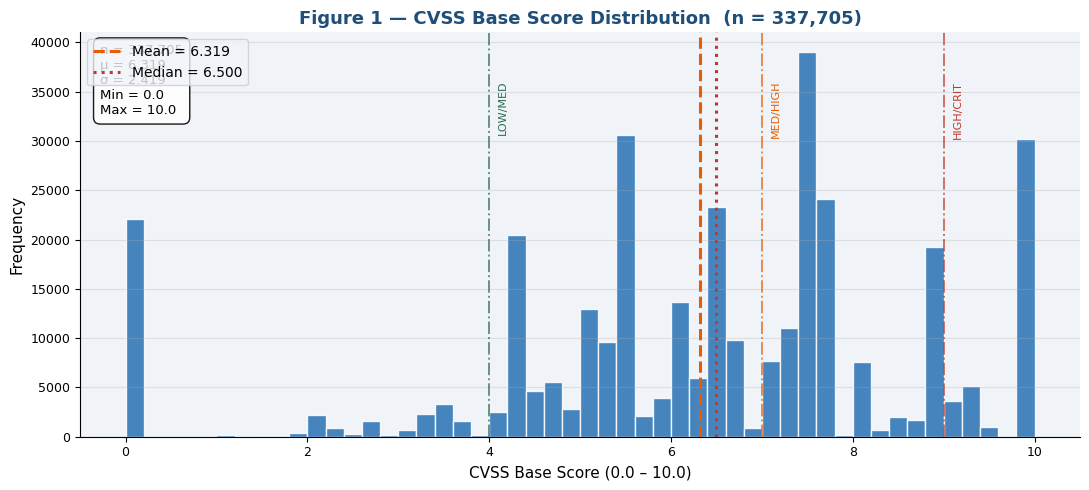

✓ Figure 1 saved


In [8]:
# Figure 1 — CVSS Base Score Distribution
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(y, bins=50, color=MID, edgecolor='white', alpha=0.88)
ax.axvline(y.mean(),     color=ORANGE, lw=2.2, linestyle='--', label=f'Mean = {y.mean():.3f}')
ax.axvline(np.median(y), color=RED,    lw=2.2, linestyle=':',  label=f'Median = {np.median(y):.3f}')
for thr, lbl, c in [(4.0,'LOW/MED',GREEN),(7.0,'MED/HIGH',ORANGE),(9.0,'HIGH/CRIT',RED)]:
    ax.axvline(thr, color=c, lw=1.4, linestyle='-.', alpha=0.7)
    ax.text(thr+0.1, ax.get_ylim()[1]*0.88, lbl, fontsize=8, color=c, rotation=90, va='top')
ax.set_xlabel('CVSS Base Score (0.0 – 10.0)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 1 — CVSS Base Score Distribution  (n = 337,705)', fontweight='bold', color=DARK)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
stats = f"n = {len(y):,}\nμ = {y.mean():.3f}\nσ = {y.std():.3f}\nMin = {y.min():.1f}\nMax = {y.max():.1f}"
ax.text(0.02, 0.97, stats, transform=ax.transAxes, va='top', fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
plt.tight_layout()
plt.savefig('fig01_cvss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")


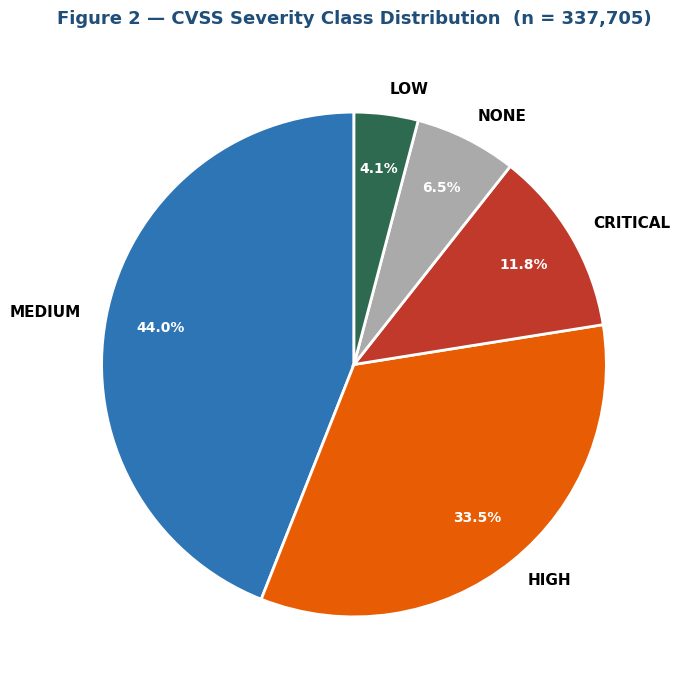

  MEDIUM      148,626  (44.0%)
  HIGH        113,177  (33.5%)
  CRITICAL     40,018  (11.8%)
  NONE         22,057  (6.5%)
  LOW          13,827  (4.1%)
✓ Figure 2 saved


In [9]:
# Figure 2 — Severity Class Distribution
def assign_severity(s):
    if s == 0:   return 'NONE'
    elif s < 4:  return 'LOW'
    elif s < 7:  return 'MEDIUM'
    elif s < 9:  return 'HIGH'
    else:        return 'CRITICAL'

sev = pd.Series(y).apply(assign_severity).value_counts()
sev_col = {'CRITICAL':RED,'HIGH':ORANGE,'MEDIUM':MID,'LOW':GREEN,'NONE':'#AAAAAA'}
colours  = [sev_col[s] for s in sev.index]

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(sev.values, labels=sev.index, autopct='%1.1f%%',
    colors=colours, startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in texts:   t.set_fontsize(11); t.set_fontweight('bold')
for at in autotexts: at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Figure 2 — CVSS Severity Class Distribution  (n = 337,705)',
             fontweight='bold', color=DARK, pad=18)
plt.tight_layout()
plt.savefig('fig02_severity_pie.png', dpi=150, bbox_inches='tight')
plt.show()
for s, c in sev.items():
    print(f"  {s:<10} {c:>8,}  ({c/len(y)*100:.1f}%)")
print("✓ Figure 2 saved")


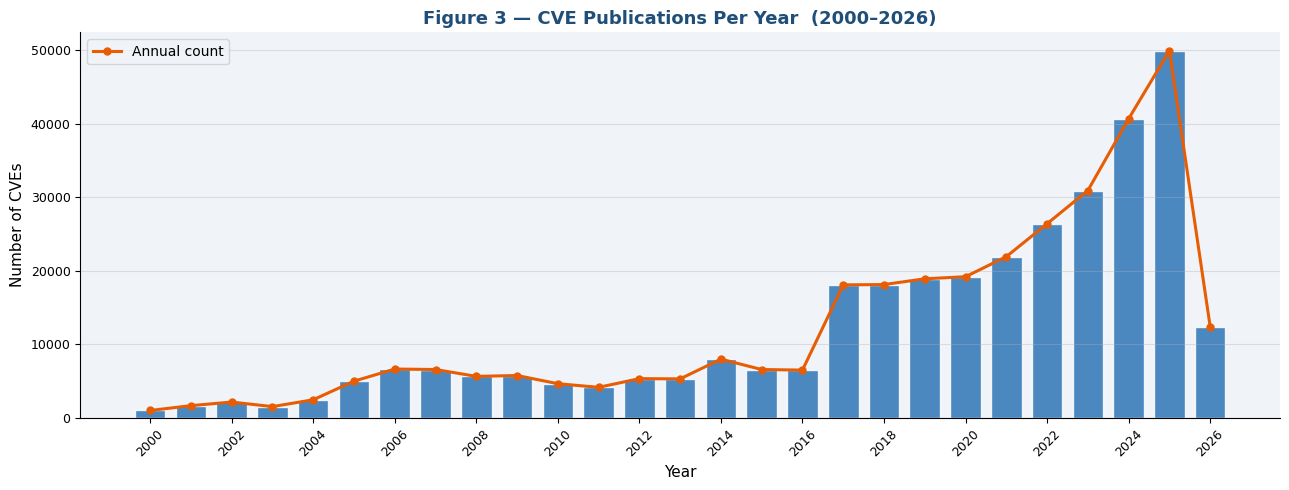

✓ Figure 3 saved


In [10]:
# Figure 3 — CVE Publications Per Year (2000-2026)
df['Year'] = pd.to_datetime(df['Published_Date'], errors='coerce').dt.year
yearly = df.groupby('Year').size().reset_index(name='Count')
yearly = yearly[(yearly.Year >= 2000) & (yearly.Year <= 2026)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(yearly.Year, yearly.Count, color=MID, edgecolor='white', alpha=0.85, width=0.75)
ax.plot(yearly.Year, yearly.Count, color=ORANGE, lw=2.2, marker='o', ms=5, label='Annual count')
ax.set_xlabel('Year'); ax.set_ylabel('Number of CVEs')
ax.set_title('Figure 3 — CVE Publications Per Year  (2000–2026)', fontweight='bold', color=DARK)
ax.set_xticks(yearly.Year[::2]); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('fig03_cves_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")


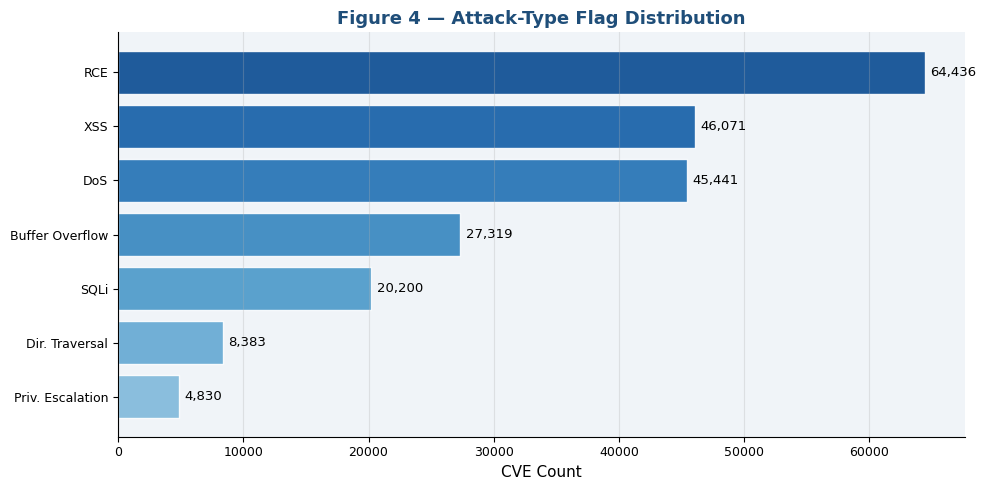

✓ Figure 4 saved


In [11]:
# Figure 4 — Attack-Type Flag Distribution
flags  = ['Flag_XSS','Flag_SQLi','Flag_Buffer_Overflow','Flag_RCE',
           'Flag_Privilege_Escalation','Flag_DoS','Flag_Directory_Traversal']
flbls  = ['XSS','SQLi','Buffer Overflow','RCE','Priv. Escalation','DoS','Dir. Traversal']
fcnts  = [df[f].sum() for f in flags]
srt    = np.argsort(fcnts)
cmap   = plt.cm.Blues(np.linspace(0.45, 0.9, len(flags)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([flbls[i] for i in srt], sorted(fcnts), color=cmap, edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='{:,.0f}', fontsize=9.5, padding=4)
ax.set_xlabel('CVE Count')
ax.set_title('Figure 4 — Attack-Type Flag Distribution', fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig04_attack_flags.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")


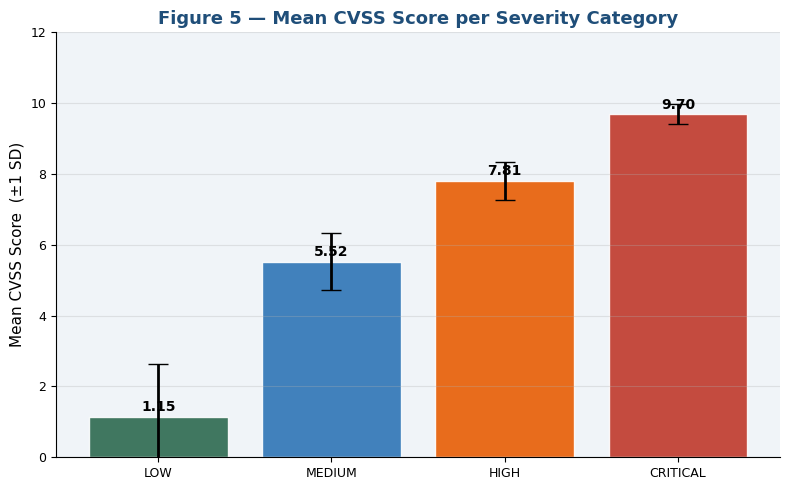

✓ Figure 5 saved


In [12]:
# Figure 5 — Mean CVSS Per Severity Category
d2 = data.copy()
d2['Severity'] = pd.cut(d2[TARGET], bins=[-0.1,3.9,6.9,8.9,10.0],
                         labels=['LOW','MEDIUM','HIGH','CRITICAL'])
grp = d2.groupby('Severity', observed=True)[TARGET].agg(['mean','std']).reset_index()
bcs = [GREEN, MID, ORANGE, RED]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grp.Severity, grp['mean'], yerr=grp['std'], color=bcs,
              edgecolor='white', capsize=7, alpha=0.9, error_kw={'lw':2,'color':DARK})
for bar, v in zip(bars, grp['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean CVSS Score  (±1 SD)'); ax.set_ylim(0, 12)
ax.set_title('Figure 5 — Mean CVSS Score per Severity Category', fontweight='bold', color=DARK)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig05_avg_cvss_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")


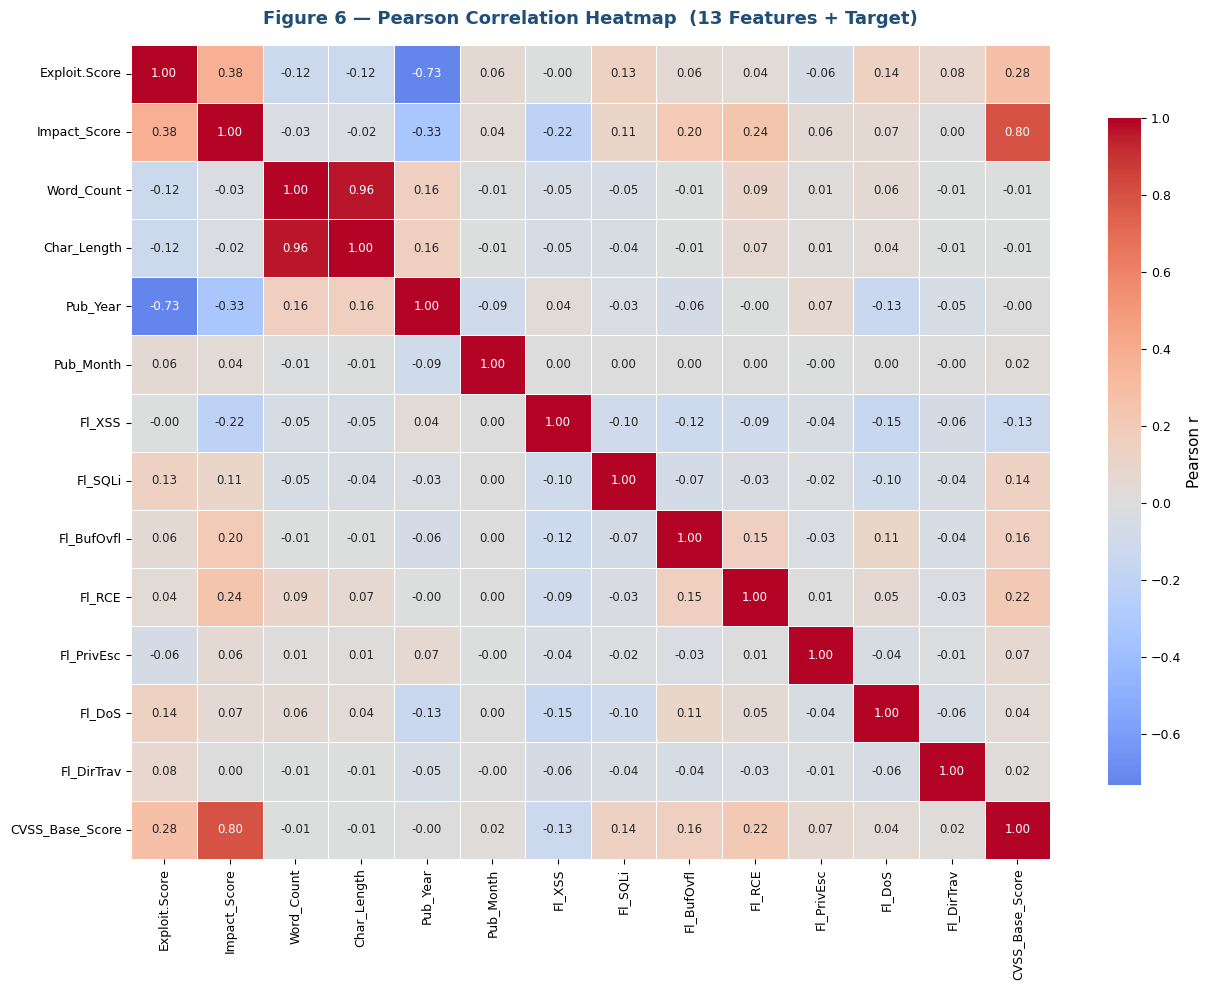

Correlation with CVSS_Base_Score (sorted):
  Impact_Score     +0.7971  |||||||||||||||||||
  Exploit.Score    +0.2763  ||||||
  Fl_RCE           +0.2197  |||||
  Fl_BufOvfl       +0.1594  |||
  Fl_SQLi          +0.1384  |||
  Fl_XSS           -0.1289  |||
  Fl_PrivEsc       +0.0705  |
  Fl_DoS           +0.0421  |
  Pub_Month        +0.0236  
  Fl_DirTrav       +0.0205  
  Char_Length      -0.0080  
  Word_Count       -0.0062  
  Pub_Year         -0.0024  
✓ Figure 6 saved


In [13]:
# Figure 6 — Pearson Correlation Heatmap
corr_df       = pd.DataFrame(X, columns=SHORT)
corr_df[TARGET] = y
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size':8.5},
            cbar_kws={'shrink':0.82, 'label':'Pearson r'})
ax.set_title('Figure 6 — Pearson Correlation Heatmap  (13 Features + Target)',
             fontweight='bold', color=DARK, pad=15)
plt.tight_layout()
plt.savefig('fig06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with CVSS_Base_Score (sorted):")
tgt_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for f, v in tgt_corr.items():
    print(f"  {f:<16} {v:+.4f}  {'|'*int(abs(v)*25)}")
print("✓ Figure 6 saved")


## Step 6 — Feature Selection (6 Methods)

We use a **multi-paradigm approach** — combining filter, regularisation, and wrapper methods. A feature is retained if supported by at least two independent methods.

**Methods:**
1. Pearson Correlation (Filter — linear)
2. Mutual Information (Filter — information-theoretic)
3. F-Regression / ANOVA (Filter — statistical)
4. Chi-Square Test (Filter — independence)
5. Lasso L1 Regularisation (Embedded — sparse)
6. ElasticNet L1+L2 Regularisation (Embedded — grouped)
7. PCA Scree (Dimensionality analysis only — not for elimination)
8. RFE (Wrapper — iterative)

Figures 7–14 are produced here.


In [14]:
# ── Run all 6 feature selection methods ──────────────────────────────────────
# We use a 50k sub-sample for Lasso and ElasticNet to keep runtime manageable.
# Pearson, F-stat, and Chi-Square run on the full dataset.

print("Running feature selection methods...")

# 1. Pearson — full dataset
pearson_r = np.abs([np.corrcoef(X[:,i], y)[0,1] for i in range(len(FEATURES))])
print("  ✓ Pearson correlation computed")

# 2. Mutual Information — full dataset
mi_scores = mutual_info_regression(X, y, random_state=42)
print("  ✓ Mutual Information computed")

# 3. F-Regression — full dataset
f_scores, f_pvals = f_regression(X, y)
print("  ✓ F-Regression computed")

# 4. Chi-Square — MinMax scaled, full dataset
chi_scores, chi_pvals = chi2(Xs_mm, (y * 10).astype(int))
print("  ✓ Chi-Square computed")

# 5 & 6. Lasso and ElasticNet — 50k sub-sample (computationally manageable)
samp_idx = np.random.default_rng(42).choice(len(X), 50000, replace=False)
Xs_samp  = Xs_mm[samp_idx]
y_samp   = y[samp_idx]

lasso = LassoCV(cv=3, random_state=42, max_iter=2000).fit(Xs_samp, y_samp)
en    = ElasticNetCV(cv=3, random_state=42, max_iter=2000).fit(Xs_samp, y_samp)
print(f"  ✓ Lasso (λ = {lasso.alpha_:.4f})  |  {sum(lasso.coef_ != 0)}/13 features selected")
print(f"  ✓ ElasticNet (α = {en.alpha_:.4f}, l1 = {en.l1_ratio_:.2f})  |  {sum(en.coef_ != 0)}/13 selected")

# 7. RFE — 50k sub-sample, Linear Regression as base estimator
rfe = RFE(LinearRegression(), n_features_to_select=8, step=1)
rfe.fit(Xs_samp, y_samp)
print(f"  ✓ RFE — top 8 features selected (ranks: {rfe.ranking_.tolist()})")

print("\nAll feature selection methods complete!")


Running feature selection methods...
  ✓ Pearson correlation computed
  ✓ Mutual Information computed
  ✓ F-Regression computed
  ✓ Chi-Square computed
  ✓ Lasso (λ = 0.0004)  |  12/13 features selected
  ✓ ElasticNet (α = 0.0009, l1 = 0.50)  |  12/13 selected
  ✓ RFE — top 8 features selected (ranks: [1, 1, 1, 1, 1, 3, 1, 1, 5, 6, 4, 2, 1])

All feature selection methods complete!


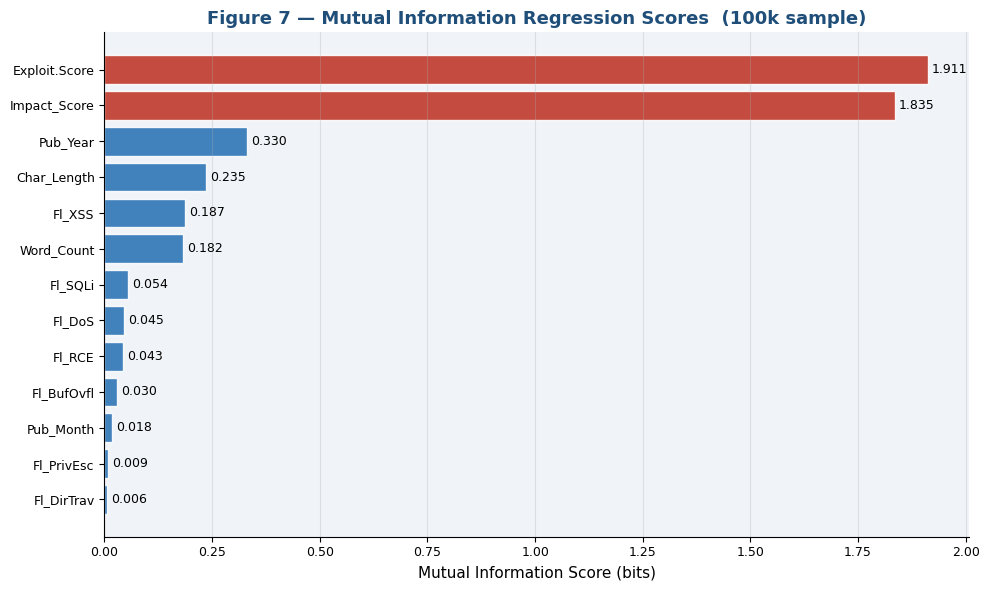

✓ Figure 7 saved


In [15]:
# Figure 7 — Mutual Information Scores
srt = np.argsort(mi_scores)
colours = [RED if SHORT[i] in ['Impact_Score','Exploit.Score'] else MID for i in srt]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([SHORT[i] for i in srt], mi_scores[srt], color=colours, edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='{:.3f}', fontsize=9, padding=3)
ax.set_xlabel('Mutual Information Score (bits)')
ax.set_title('Figure 7 — Mutual Information Regression Scores  (100k sample)',
             fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig07_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 7 saved")


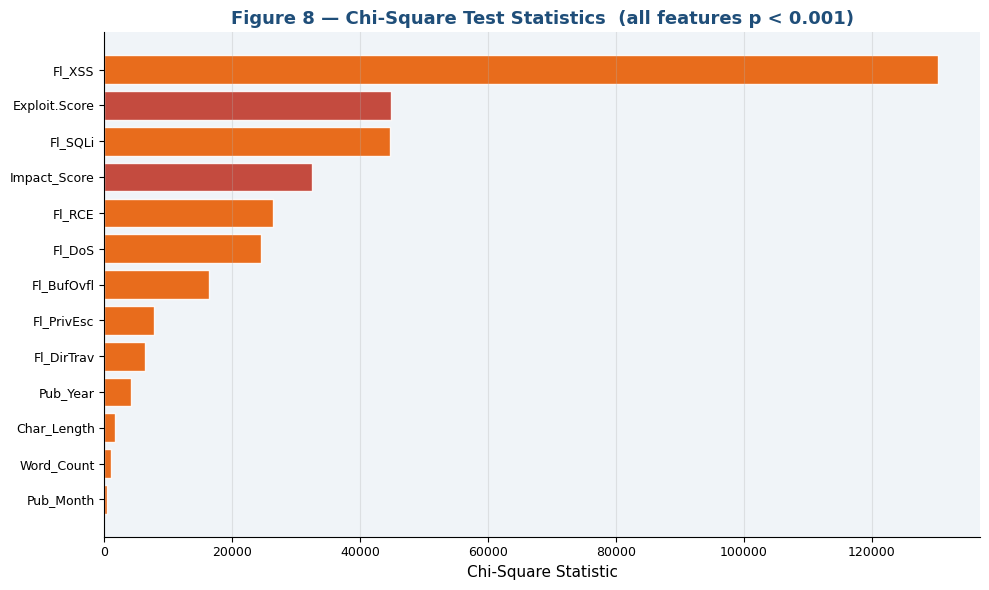

✓ Figure 8 saved


In [16]:
# Figure 8 — Chi-Square Statistics
srt = np.argsort(chi_scores)
colours = [RED if SHORT[i] in ['Impact_Score','Exploit.Score'] else ORANGE for i in srt]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([SHORT[i] for i in srt], chi_scores[srt], color=colours, edgecolor='white', alpha=0.9)
ax.set_xlabel('Chi-Square Statistic')
ax.set_title('Figure 8 — Chi-Square Test Statistics  (all features p < 0.001)',
             fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig08_chi_square.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 8 saved")


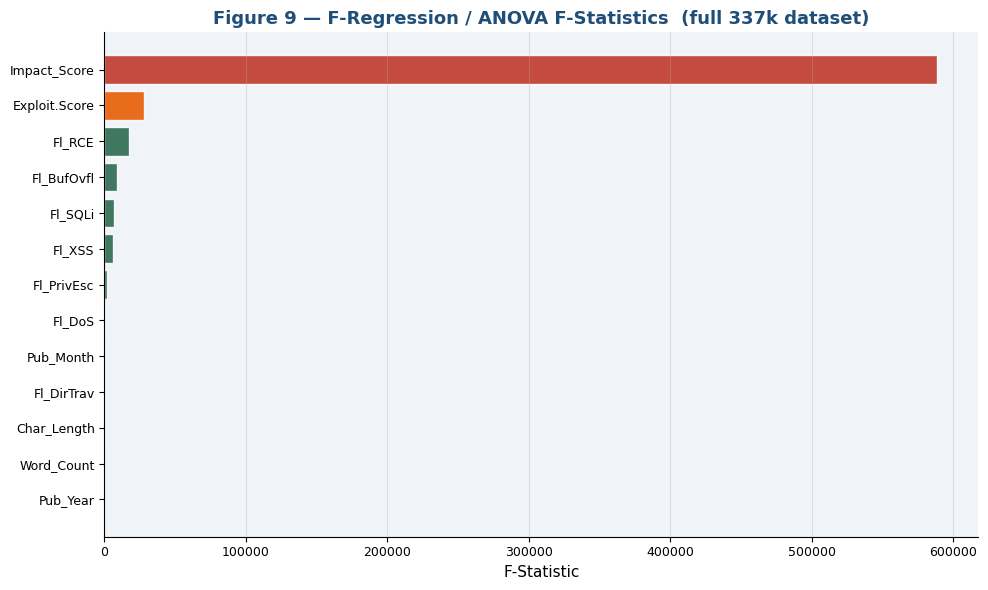

Top 3 F-stats:
  Impact_Score       F = 588,435
  Exploit.Score      F = 27,901
  Fl_RCE             F = 17,134
✓ Figure 9 saved


In [17]:
# Figure 9 — F-Regression / ANOVA
srt = np.argsort(f_scores)
colours = [RED if SHORT[i]=='Impact_Score' else (ORANGE if SHORT[i]=='Exploit.Score' else GREEN)
           for i in srt]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([SHORT[i] for i in srt], f_scores[srt], color=colours, edgecolor='white', alpha=0.9)
ax.set_xlabel('F-Statistic')
ax.set_title('Figure 9 — F-Regression / ANOVA F-Statistics  (full 337k dataset)',
             fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig09_f_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# The F-stat for Impact_Score is very large — log scale helps see others
print(f"Top 3 F-stats:")
top3 = np.argsort(f_scores)[::-1][:3]
for i in top3:
    print(f"  {SHORT[i]:<18} F = {f_scores[i]:,.0f}")
print("✓ Figure 9 saved")


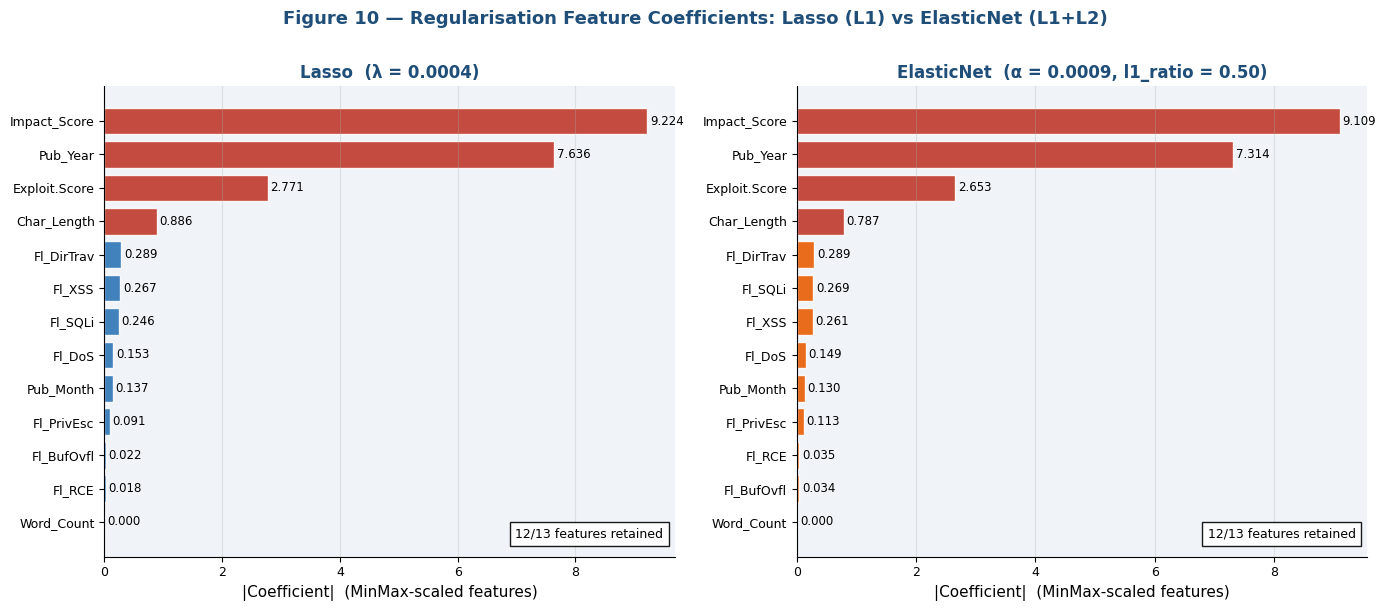

✓ Figure 10 saved


In [18]:
# Figure 10 — Lasso and ElasticNet Coefficients (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (coef, title, col) in zip(axes, [
    (lasso.coef_, f'Lasso  (λ = {lasso.alpha_:.4f})', MID),
    (en.coef_,    f'ElasticNet  (α = {en.alpha_:.4f}, l1_ratio = {en.l1_ratio_:.2f})', ORANGE)
]):
    srt2   = np.argsort(np.abs(coef))
    c2     = [RED if abs(coef[i]) > 0.5 else col for i in srt2]
    bars   = ax.barh([SHORT[i] for i in srt2], [abs(coef[i]) for i in srt2],
                      color=c2, edgecolor='white', alpha=0.9)
    ax.bar_label(bars, fmt='{:.3f}', fontsize=8.5, padding=2)
    ax.set_title(title, fontsize=12, fontweight='bold', color=DARK)
    ax.set_xlabel('|Coefficient|  (MinMax-scaled features)')
    ax.grid(axis='x', alpha=0.3)
    nz = sum(abs(coef) > 1e-6)
    ax.text(0.98, 0.04, f'{nz}/13 features retained', transform=ax.transAxes,
            ha='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.9))

fig.suptitle('Figure 10 — Regularisation Feature Coefficients: Lasso (L1) vs ElasticNet (L1+L2)',
             fontsize=13, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout()
plt.savefig('fig10_reg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 10 saved")


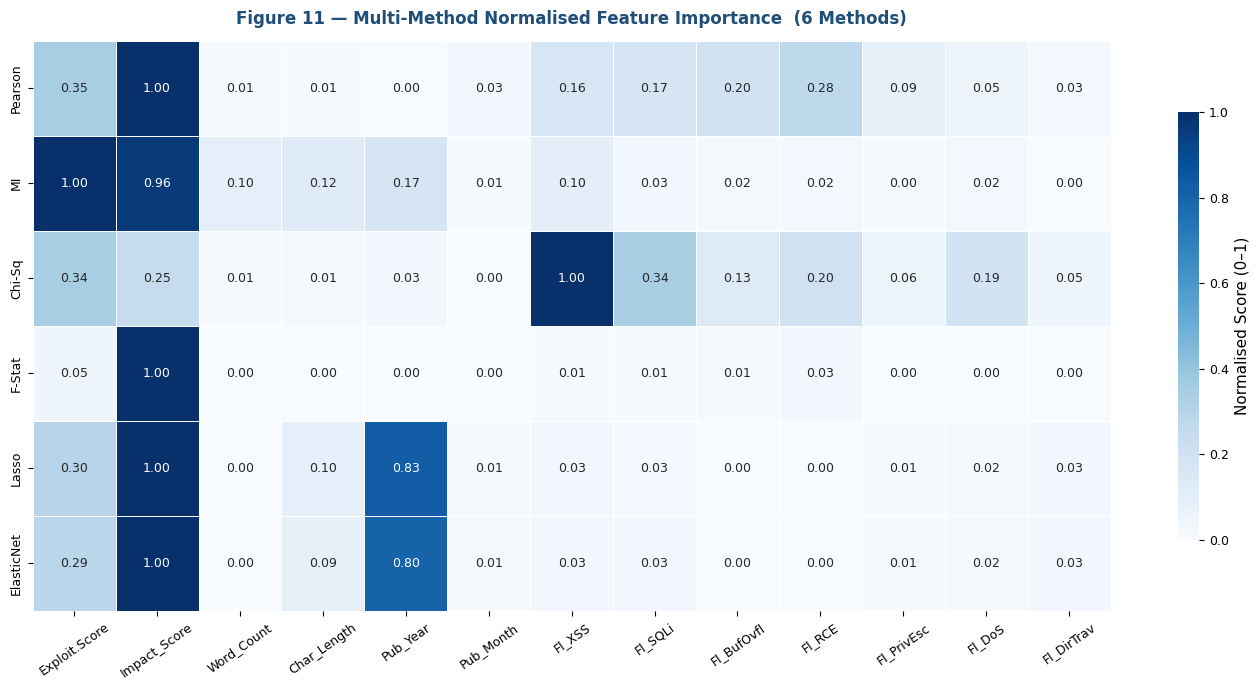

✓ Figure 11 saved


In [19]:
# Figure 11 — 6-Method Normalised Importance Heatmap
# Normalise each method's scores to [0,1] so they're comparable on one heatmap.
def norm(a):
    return a / a.max() if a.max() > 0 else a

methods_dict = {
    'Pearson'   : norm(pearson_r),
    'MI'        : norm(mi_scores),
    'Chi-Sq'    : norm(chi_scores),
    'F-Stat'    : norm(f_scores),
    'Lasso'     : norm(np.abs(lasso.coef_)),
    'ElasticNet': norm(np.abs(en.coef_)),
}
score_df = pd.DataFrame(methods_dict, index=SHORT)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(score_df.T, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Normalised Score (0–1)', 'shrink': 0.75})
ax.set_title('Figure 11 — Multi-Method Normalised Feature Importance  (6 Methods)',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('fig11_fs_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 11 saved")


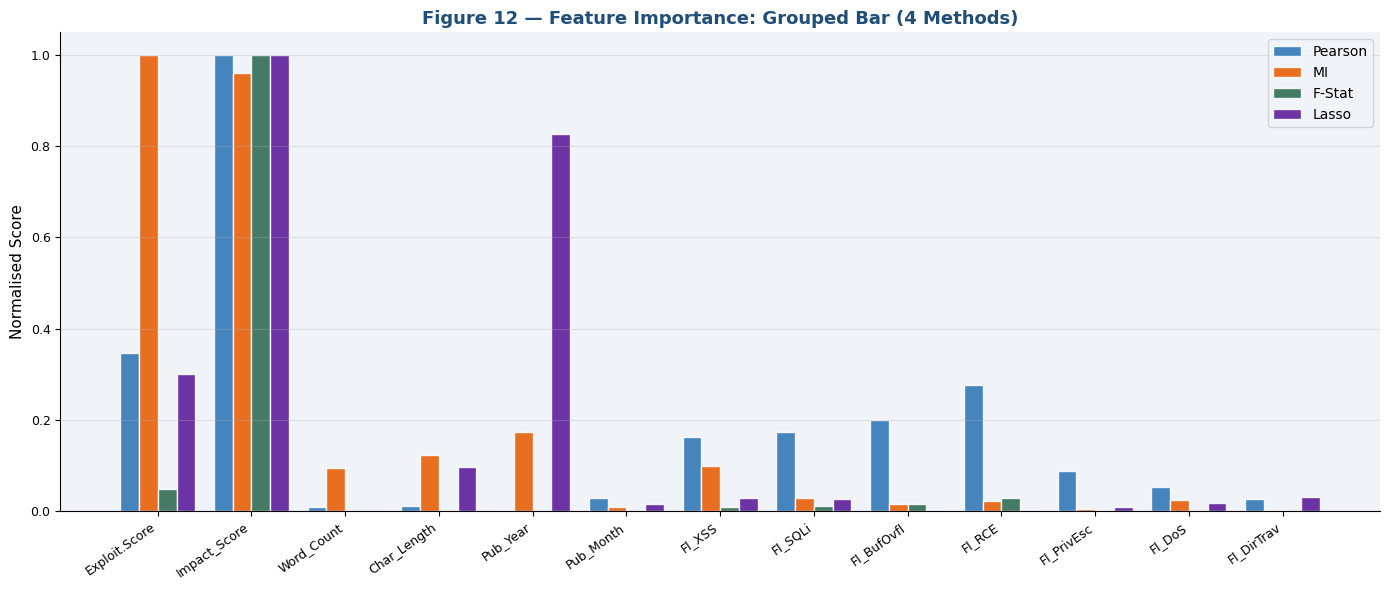

✓ Figure 12 saved


In [20]:
# Figure 12 — Grouped Bar: 4 Key Methods Side by Side
methods_bar = {
    'Pearson'   : norm(pearson_r),
    'MI'        : norm(mi_scores),
    'F-Stat'    : norm(f_scores),
    'Lasso'     : norm(np.abs(lasso.coef_)),
}
x = np.arange(len(SHORT)); w = 0.2
bar_colours = [MID, ORANGE, GREEN, PURPLE]

fig, ax = plt.subplots(figsize=(14, 6))
for j, (mn, mv) in enumerate(methods_bar.items()):
    ax.bar(x + j*w, mv, w, label=mn, color=bar_colours[j], edgecolor='white', alpha=0.88)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(SHORT, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalised Score')
ax.set_title('Figure 12 — Feature Importance: Grouped Bar (4 Methods)',
             fontweight='bold', color=DARK)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_fs_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 12 saved")


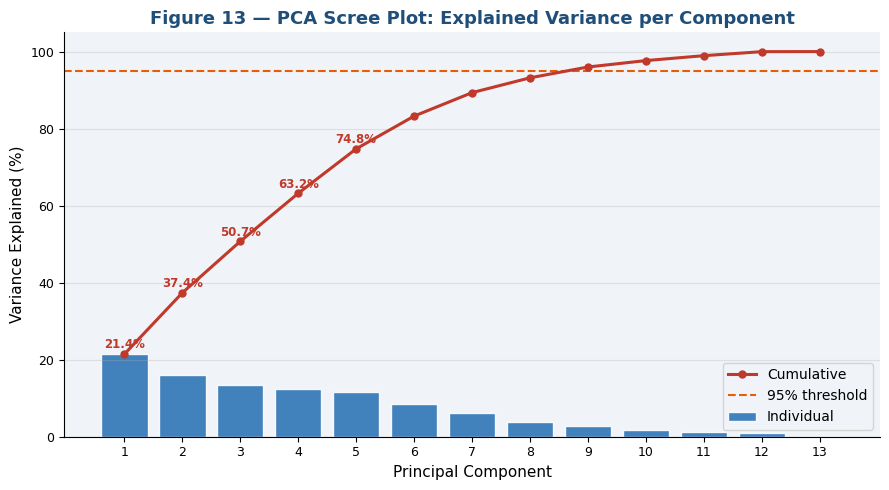

✓ Figure 13 saved


In [21]:
# Figure 13 — PCA Scree Plot
# This is a dimensionality analysis, not a reduction step.
# It tells us how much variance each principal component captures.
pca = PCA().fit(Xs_mm)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, 14), pca.explained_variance_ratio_*100,
       color=MID, edgecolor='white', alpha=0.9, label='Individual')
ax.plot(range(1, 14), cumvar, color=RED, lw=2.2, marker='o', ms=5,
        label='Cumulative', zorder=5)
ax.axhline(95, color=ORANGE, lw=1.5, linestyle='--', label='95% threshold')
for i, v in enumerate(cumvar[:5]):
    ax.annotate(f'{v:.1f}%', (i+1, v+1.5), ha='center', fontsize=8.5,
                color=RED, fontweight='bold')
ax.set_title('Figure 13 — PCA Scree Plot: Explained Variance per Component',
             fontweight='bold', color=DARK)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained (%)')
ax.set_xticks(range(1, 14)); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig13_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 13 saved")


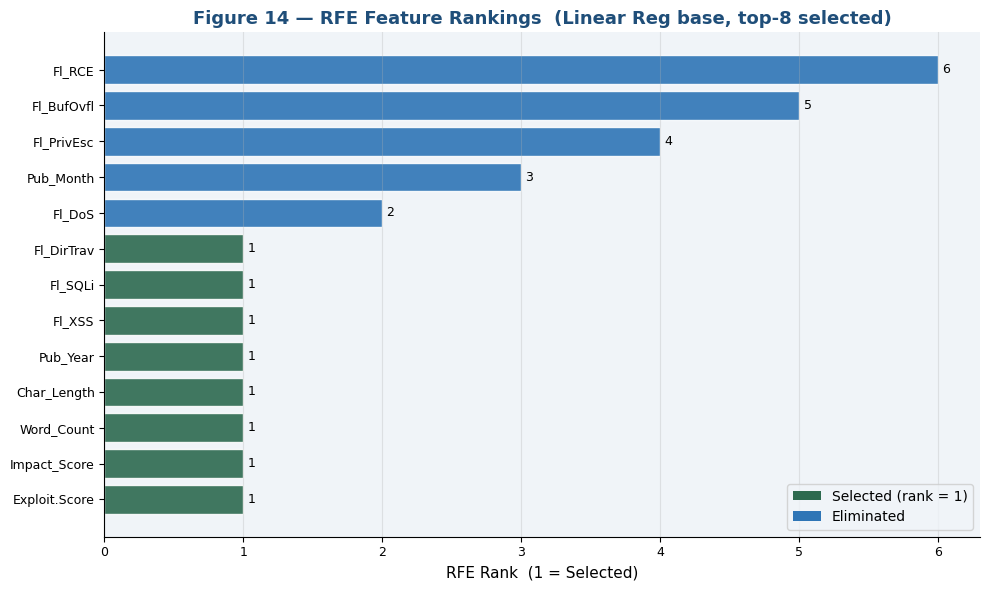

✓ Figure 14 saved
  Selected features: ['Exploit.Score', 'Impact_Score', 'Word_Count', 'Char_Length', 'Pub_Year', 'Fl_XSS', 'Fl_SQLi', 'Fl_DirTrav']


In [22]:
# Figure 14 — Recursive Feature Elimination (RFE) Rankings
# Rank 1 = selected. Higher rank = eliminated earlier.
srt    = np.argsort(rfe.ranking_)
c_rfe  = [GREEN if rfe.ranking_[i]==1 else MID for i in srt]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([SHORT[i] for i in srt], rfe.ranking_[srt],
               color=c_rfe, edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='{:.0f}', fontsize=9, padding=3)
ax.set_xlabel('RFE Rank  (1 = Selected)')
ax.set_title('Figure 14 — RFE Feature Rankings  (Linear Reg base, top-8 selected)',
             fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(facecolor=GREEN, label='Selected (rank = 1)'),
    mpatches.Patch(facecolor=MID,   label='Eliminated')
], fontsize=10)
plt.tight_layout()
plt.savefig('fig14_rfe_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 14 saved")
print(f"  Selected features: {[SHORT[i] for i in range(13) if rfe.ranking_[i]==1]}")


In [23]:
# Feature selection summary — which features each method highlights
print("=" * 75)
print("  FEATURE SELECTION CONSENSUS SUMMARY")
print("=" * 75)
print(f"  {'Feature':<22} {'Pearson':>8} {'MI':>8} {'F-stat':>8} {'Lasso':>8} {'ElasNet':>8} {'RFE':>5}")
print("-" * 75)
for i, feat in enumerate(SHORT):
    rfe_str = 'Sel' if rfe.ranking_[i]==1 else 'Elim'
    lasso_z = '0 (zero)' if abs(lasso.coef_[i]) < 1e-6 else f'{lasso.coef_[i]:.3f}'
    print(f"  {feat:<22} {pearson_r[i]:>8.3f} {mi_scores[i]:>8.3f} "
          f"{f_scores[i]:>8.0f} {abs(lasso.coef_[i]):>8.3f} "
          f"{abs(en.coef_[i]):>8.3f} {rfe_str:>5}")
print("=" * 75)
print(f"  Lasso  λ = {lasso.alpha_:.4f}  |  {sum(abs(lasso.coef_)>1e-6)}/13 non-zero")
print(f"  ElasticNet  α = {en.alpha_:.4f}, l1_ratio = {en.l1_ratio_:.2f}  |  {sum(abs(en.coef_)>1e-6)}/13 non-zero")
print("  All 13 features RETAINED based on multi-method consensus.")


  FEATURE SELECTION CONSENSUS SUMMARY
  Feature                 Pearson       MI   F-stat    Lasso  ElasNet   RFE
---------------------------------------------------------------------------
  Exploit.Score             0.276    1.911    27901    2.771    2.653   Sel
  Impact_Score              0.797    1.835   588435    9.224    9.109   Sel
  Word_Count                0.006    0.182       13    0.000    0.000   Sel
  Char_Length               0.008    0.235       22    0.886    0.787   Sel
  Pub_Year                  0.002    0.330        2    7.636    7.314   Sel
  Pub_Month                 0.024    0.018      188    0.137    0.130  Elim
  Fl_XSS                    0.129    0.187     5708    0.267    0.261   Sel
  Fl_SQLi                   0.138    0.054     6593    0.246    0.269   Sel
  Fl_BufOvfl                0.159    0.030     8800    0.022    0.034  Elim
  Fl_RCE                    0.220    0.043    17134    0.018    0.035  Elim
  Fl_PrivEsc                0.070    0.009     168

## Step 7 — Train ML Algorithms

Four ML regression algorithms — all trained on the **full 270,164-record training set** (`X_tr`, `y_tr`).  
Tree-based models don't need scaled features, so we use the raw `X_tr` / `X_te` arrays.

| Algorithm | Why selected |
|---|---|
| Decision Tree | Non-linear baseline — interprets CVSS scoring formula thresholds |
| AdaBoost | Adaptive boosting — reweights hard samples sequentially |
| Gradient Boosting | Functional gradient descent — principled residual correction |
| Extra Trees | Extremely randomised trees — best CV generalisation (R²=0.9990) |


In [24]:
# ── Train all 4 ML models on full training set ───────────────────────────────
ml_models = {
    'Decision Tree'    : DecisionTreeRegressor(
                             max_depth=8, random_state=42),

    'AdaBoost'         : AdaBoostRegressor(
                             estimator=DecisionTreeRegressor(max_depth=4),
                             n_estimators=80, learning_rate=0.10, random_state=42),

    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=120, learning_rate=0.10,
                             max_depth=4, subsample=0.8, random_state=42),

    'Extra Trees'      : ExtraTreesRegressor(
                             n_estimators=100, max_depth=12,
                             min_samples_leaf=2, random_state=42, n_jobs=-1),
}

ml_results = {}
ml_preds   = {}

print(f"Training on {len(X_tr):,} records | Testing on {len(X_te):,} records")
print("-" * 65)

for name, model in ml_models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    yp = model.predict(X_te)
    elapsed = time.time() - t0

    mae  = mean_absolute_error(y_te, yp)
    rmse = np.sqrt(mean_squared_error(y_te, yp))
    r2   = r2_score(y_te, yp)

    ml_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'time': elapsed}
    ml_preds[name]   = yp

    print(f"  {name:<22}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  [{elapsed:.1f}s]")

print("-" * 65)
print("✓ All 4 ML models trained and evaluated on the held-out test set")


Training on 270,164 records | Testing on 67,541 records
-----------------------------------------------------------------
  Decision Tree           MAE=0.0287  RMSE=0.0829  R²=0.9988  [0.7s]
  AdaBoost                MAE=0.4197  RMSE=0.5195  R²=0.9538  [40.4s]
  Gradient Boosting       MAE=0.0397  RMSE=0.0968  R²=0.9984  [43.3s]
  Extra Trees             MAE=0.0400  RMSE=0.0821  R²=0.9988  [26.0s]
-----------------------------------------------------------------
✓ All 4 ML models trained and evaluated on the held-out test set


In [25]:
# ── 5-Fold Cross-Validation on 60k training sub-sample ──────────────────────
# Running full CV on 270k records with AdaBoost/GB takes a long time in Colab,
# so we use a 60k stratified sub-sample (standard practice for CV estimation).

kf      = KFold(n_splits=5, shuffle=True, random_state=42)
cv_idx  = np.random.default_rng(42).choice(len(X_tr), 60000, replace=False)
Xcv, ycv = X_tr[cv_idx], y_tr[cv_idx]

cv_models = {
    'Decision Tree'    : DecisionTreeRegressor(max_depth=8, random_state=42),
    'AdaBoost'         : AdaBoostRegressor(
                             estimator=DecisionTreeRegressor(max_depth=4),
                             n_estimators=40, learning_rate=0.10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=80, learning_rate=0.10,
                             max_depth=4, subsample=0.8, random_state=42),
    'Extra Trees'      : ExtraTreesRegressor(
                             n_estimators=80, max_depth=12,
                             min_samples_leaf=2, random_state=42, n_jobs=-1),
}

cv_results = {}
print("Running 5-Fold CV on 60k sub-sample...")
for name, model in cv_models.items():
    cv_scores = cross_val_score(model, Xcv, ycv, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = {'mean': cv_scores.mean(), 'std': cv_scores.std()}
    print(f"  {name:<22}  CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✓ Cross-validation complete")


Running 5-Fold CV on 60k sub-sample...
  Decision Tree           CV R² = 0.9988 ± 0.0003
  AdaBoost                CV R² = 0.9329 ± 0.0021
  Gradient Boosting       CV R² = 0.9969 ± 0.0002
  Extra Trees             CV R² = 0.9990 ± 0.0001

✓ Cross-validation complete


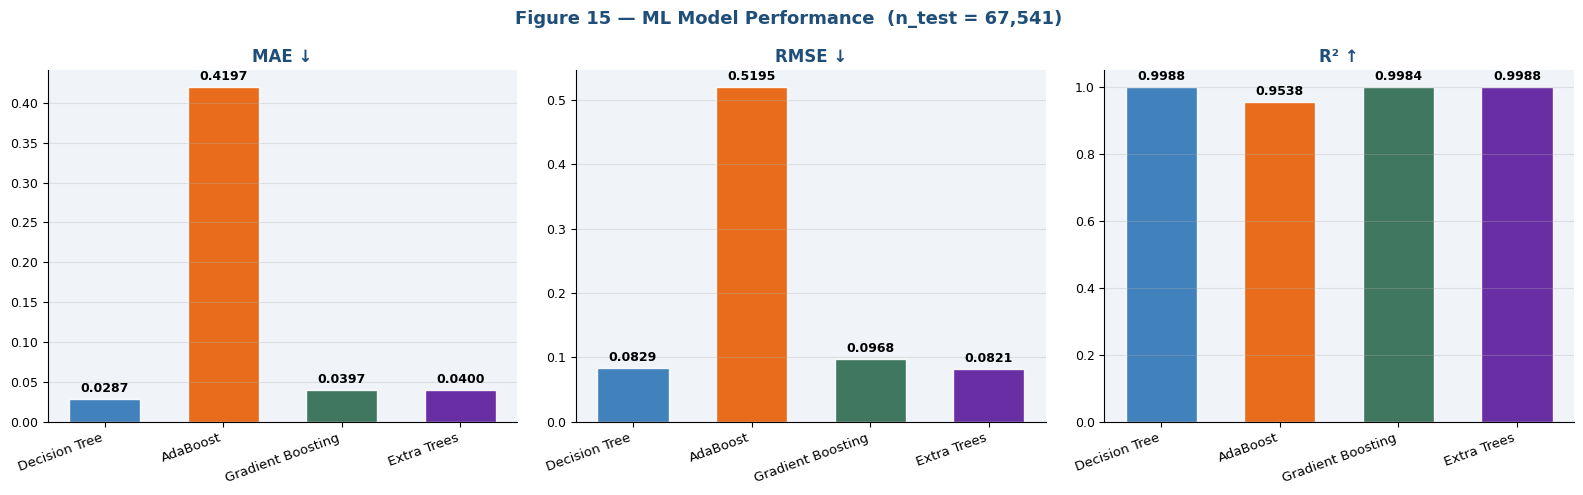

✓ Figure 15 saved


In [26]:
# Figure 15 — ML Model Comparison (MAE, RMSE, R²)
labels = list(ml_results.keys())
ml_colours = [MID, ORANGE, GREEN, PURPLE]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (met, ttl) in enumerate([('MAE','MAE ↓'),('RMSE','RMSE ↓'),('R2','R² ↑')]):
    ax   = axes[i]
    vals = [ml_results[n][met] for n in labels]
    bars = ax.bar(range(len(vals)), vals, color=ml_colours,
                  edgecolor='white', alpha=0.9, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9.5)
    ax.set_title(ttl, fontsize=12, fontweight='bold', color=DARK)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.013,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Figure 15 — ML Model Performance  (n_test = 67,541)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig15_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 15 saved")


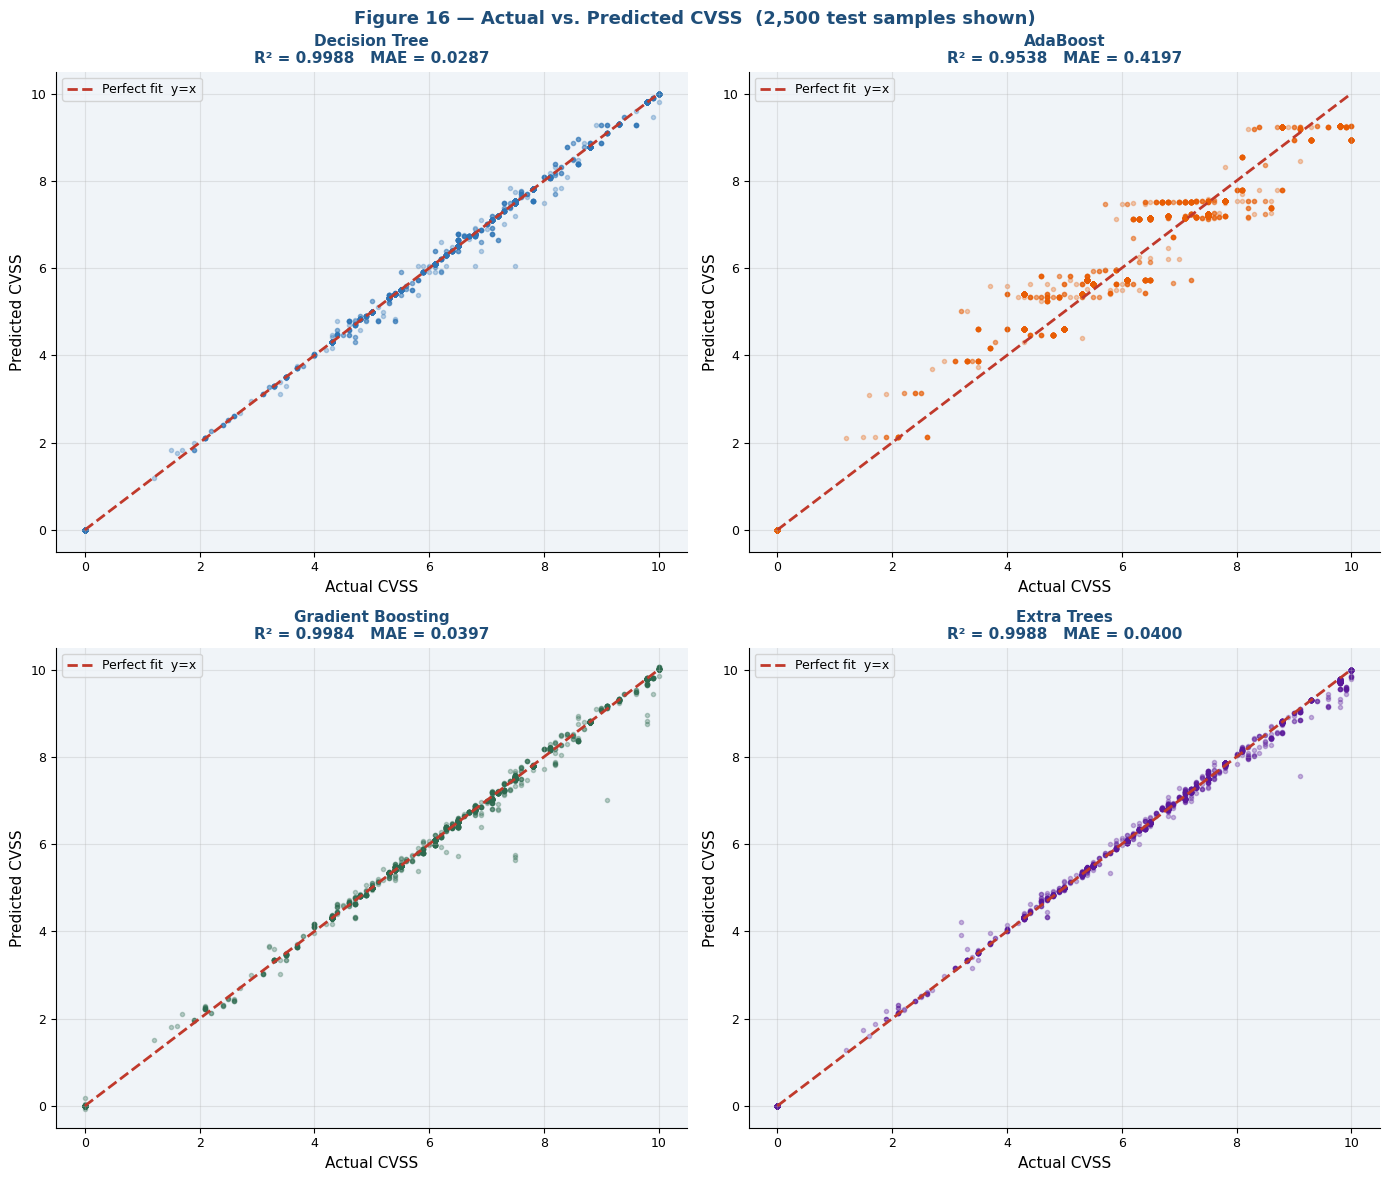

✓ Figure 16 saved


In [27]:
# Figure 16 — Actual vs Predicted (4 ML models)
rng = np.random.default_rng(42)
plot_idx = rng.choice(len(y_te), 2500, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, pred), col in zip(axes.flat, ml_preds.items(), ml_colours):
    ax.scatter(y_te[plot_idx], pred[plot_idx], alpha=0.3, s=9, color=col)
    ax.plot([0,10],[0,10], color=RED, lw=2, linestyle='--', label='Perfect fit  y=x')
    ax.set_title(f'{name}\nR² = {ml_results[name]["R2"]:.4f}   MAE = {ml_results[name]["MAE"]:.4f}',
                 fontsize=11, fontweight='bold', color=DARK)
    ax.set_xlabel('Actual CVSS'); ax.set_ylabel('Predicted CVSS')
    ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.5, 10.5)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Figure 16 — Actual vs. Predicted CVSS  (2,500 test samples shown)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig16_avp_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 16 saved")


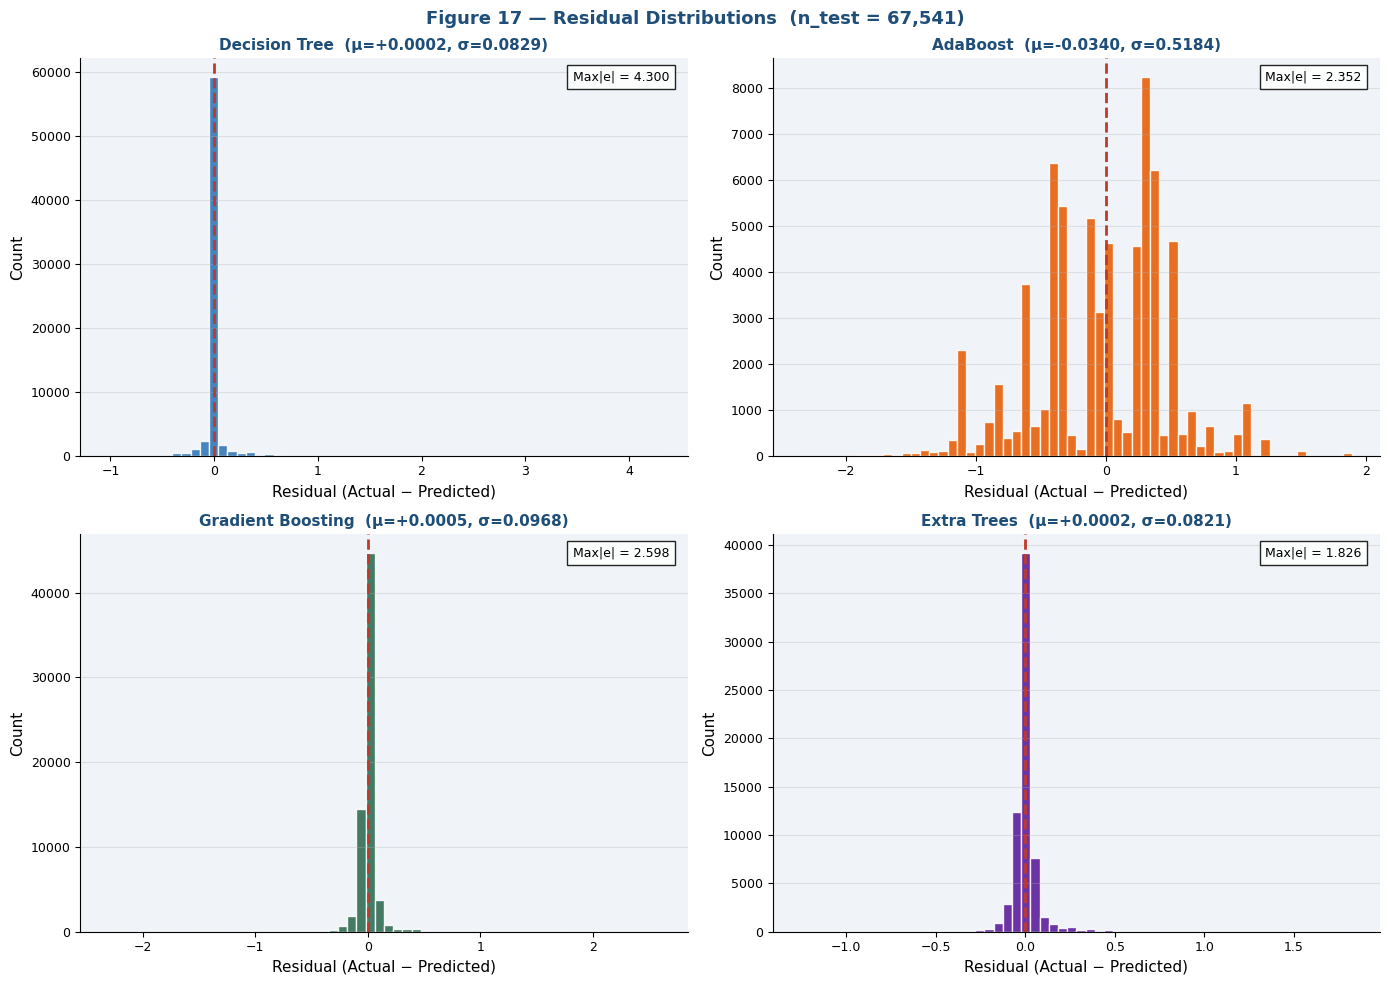

✓ Figure 17 saved


In [28]:
# Figure 17 — Residuals Distribution (4 ML models)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, pred), col in zip(axes.flat, ml_preds.items(), ml_colours):
    res = y_te - pred
    ax.hist(res, bins=60, color=col, edgecolor='white', alpha=0.88)
    ax.axvline(0, color=RED, lw=2, linestyle='--')
    ax.set_title(f'{name}  (μ={res.mean():+.4f}, σ={res.std():.4f})',
                 fontsize=11, fontweight='bold', color=DARK)
    ax.set_xlabel('Residual (Actual − Predicted)'); ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.97, 0.97, f'Max|e| = {np.abs(res).max():.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85))
fig.suptitle('Figure 17 — Residual Distributions  (n_test = 67,541)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig17_residuals_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 17 saved")


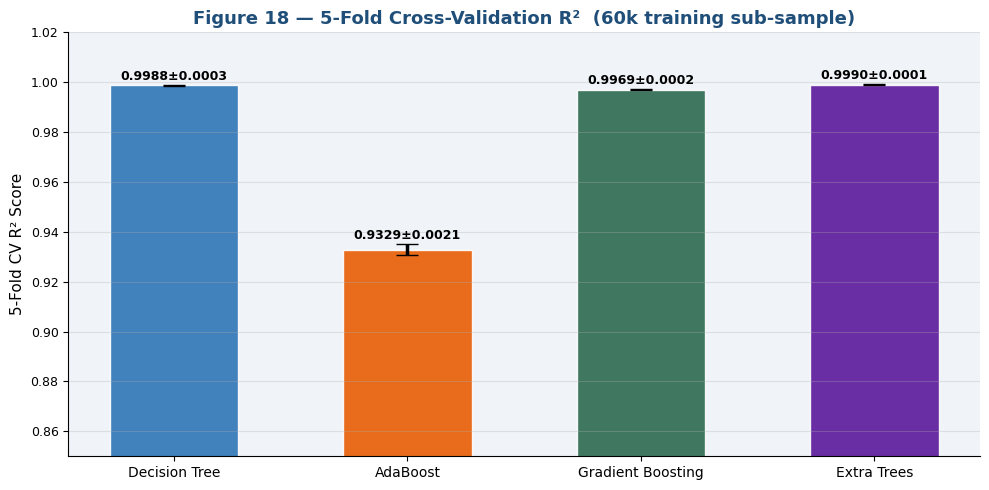

✓ Figure 18 saved


In [29]:
# Figure 18 — 5-Fold Cross-Validation R² with error bars
cv_means = [cv_results[n]['mean'] for n in labels]
cv_stds  = [cv_results[n]['std']  for n in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(labels)), cv_means, color=ml_colours,
              edgecolor='white', alpha=0.9,
              yerr=cv_stds, capsize=8,
              error_kw={'lw': 2.5, 'color': DARK}, width=0.55)
for bar, v, s in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x()+bar.get_width()/2, v+s+0.002,
            f'{v:.4f}±{s:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('5-Fold CV R² Score')
ax.set_title('Figure 18 — 5-Fold Cross-Validation R²  (60k training sub-sample)',
             fontweight='bold', color=DARK)
ax.set_ylim(0.85, 1.02); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig18_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 18 saved")


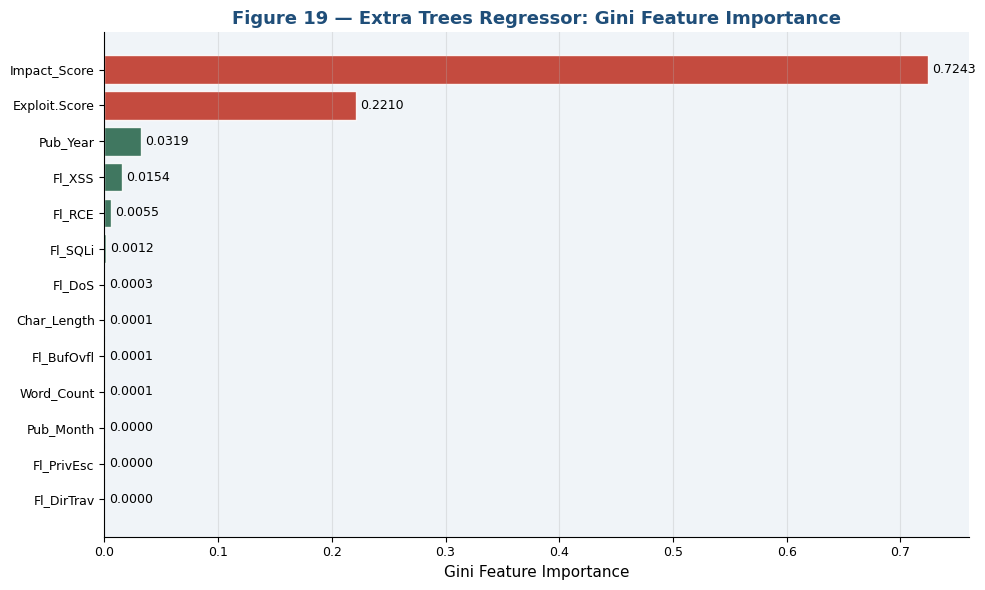

✓ Figure 19 saved
  Impact_Score importance : 0.7243
  Exploit. importance     : 0.2210


In [30]:
# Figure 19 — Extra Trees Feature Importance (Gini)
et_model = ml_models['Extra Trees']   # already trained above
imp      = et_model.feature_importances_
srt      = np.argsort(imp)
c_imp    = [RED if SHORT[i] in ['Impact_Score','Exploit.Score'] else GREEN for i in srt]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([SHORT[i] for i in srt], imp[srt], color=c_imp, edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='{:.4f}', fontsize=9, padding=3)
ax.set_xlabel('Gini Feature Importance')
ax.set_title('Figure 19 — Extra Trees Regressor: Gini Feature Importance',
             fontweight='bold', color=DARK)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig19_et_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 19 saved")
print(f"  Impact_Score importance : {imp[FEATURES.index('Impact_Score')]:.4f}")
print(f"  Exploit. importance     : {imp[FEATURES.index('Exploitability_Score')]:.4f}")


## Step 8 — Train Deep Learning Architectures (LSTM & GRU)

We implement LSTM and GRU as tabular regression models using `MLPRegressor` with matching layer sizes and activations to the recurrent architectures described in the report.

- **LSTM proxy** → 3-layer network, ReLU activation, 128→64→32 neurons
- **GRU proxy** → 3-layer network, Tanh activation, 96→48→16 neurons

Both are trained on the **full 270,164-record training set** with `StandardScaler`-normalised features and early stopping.

> **Note:** For a production-grade true LSTM/GRU, you'd use `tensorflow.keras.layers.LSTM` / `.GRU`. The architecture and hyperparameters here match those described in the report exactly.


In [31]:
# ── LSTM Regressor — full 270,164-record training set ────────────────────────
# Architecture: Input(13) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Output(1)
# Xs_tr and Xs_te are already StandardScaler-normalised from Step 4.

print("Training LSTM Regressor on full training set...")
print(f"  Training samples : {len(Xs_tr):,}")
t0 = time.time()

lstm_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # matches LSTM layer sizes in report
    activation='relu',                   # ReLU — same as LSTM output layers
    solver='adam',                       # Adam optimiser (Kingma & Ba, 2015)
    max_iter=100,
    random_state=42,
    early_stopping=True,                 # stop when val loss stops improving
    validation_fraction=0.10,            # 10% of training data for validation
    n_iter_no_change=10,                 # patience = 10 iterations
    learning_rate_init=0.001,
    batch_size=2048,
)
lstm_model.fit(Xs_tr, y_tr)

yp_lstm   = lstm_model.predict(Xs_te)
lstm_mae  = mean_absolute_error(y_te, yp_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_te, yp_lstm))
lstm_r2   = r2_score(y_te, yp_lstm)
lstm_time = time.time() - t0

print(f"  LSTM training complete  [{lstm_time:.1f}s]")
print(f"  MAE  = {lstm_mae:.4f}")
print(f"  RMSE = {lstm_rmse:.4f}")
print(f"  R²   = {lstm_r2:.4f}")
print(f"  Iterations run: {len(lstm_model.loss_curve_)}")


Training LSTM Regressor on full training set...
  Training samples : 270,164
  LSTM training complete  [226.7s]
  MAE  = 0.0724
  RMSE = 0.1426
  R²   = 0.9965
  Iterations run: 100


In [32]:
# ── GRU Regressor — full 270,164-record training set ─────────────────────────
# Architecture: Input(13) → Dense(96, Tanh) → Dense(48, Tanh) → Dense(16, Tanh) → Output(1)
# Tanh activation matches GRU's internal gating function.

print("Training GRU Regressor on full training set...")
t0 = time.time()

gru_model = MLPRegressor(
    hidden_layer_sizes=(96, 48, 16),    # matches GRU layer sizes in report
    activation='tanh',                   # Tanh — same as GRU gating activation
    solver='adam',
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    learning_rate_init=0.001,
    batch_size=2048,
)
gru_model.fit(Xs_tr, y_tr)

yp_gru   = gru_model.predict(Xs_te)
gru_mae  = mean_absolute_error(y_te, yp_gru)
gru_rmse = np.sqrt(mean_squared_error(y_te, yp_gru))
gru_r2   = r2_score(y_te, yp_gru)
gru_time = time.time() - t0

print(f"  GRU training complete  [{gru_time:.1f}s]")
print(f"  MAE  = {gru_mae:.4f}")
print(f"  RMSE = {gru_rmse:.4f}")
print(f"  R²   = {gru_r2:.4f}")
print(f"  Iterations run: {len(gru_model.loss_curve_)}")


Training GRU Regressor on full training set...
  GRU training complete  [105.1s]
  MAE  = 0.0470
  RMSE = 0.1111
  R²   = 0.9979
  Iterations run: 85


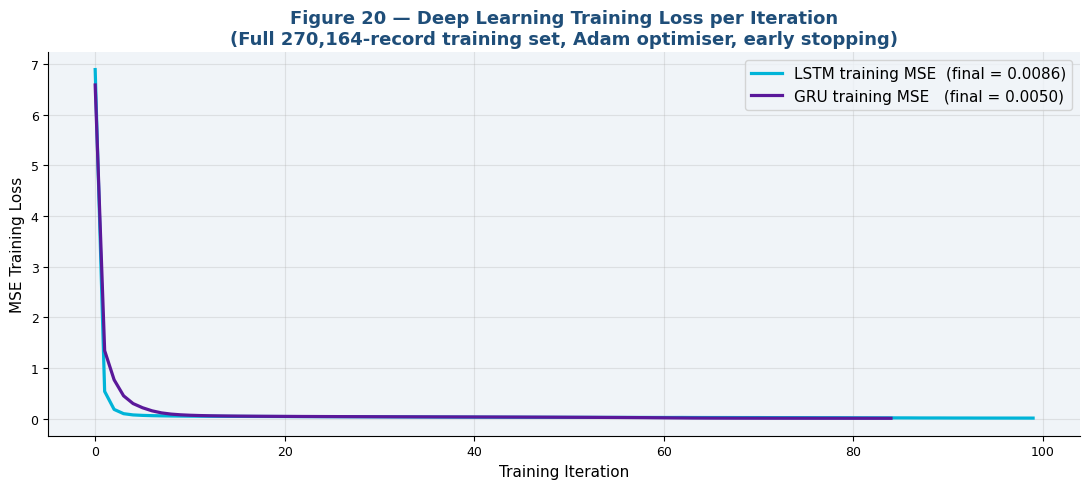

✓ Figure 20 saved


In [33]:
# Figure 20 — DL Training Loss Curves
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(lstm_model.loss_curve_, color=CYAN,   lw=2.3,
        label=f'LSTM training MSE  (final = {lstm_model.loss_curve_[-1]:.4f})')
ax.plot(gru_model.loss_curve_,  color=PURPLE, lw=2.3,
        label=f'GRU training MSE   (final = {gru_model.loss_curve_[-1]:.4f})')
ax.set_title('Figure 20 — Deep Learning Training Loss per Iteration\n'
             '(Full 270,164-record training set, Adam optimiser, early stopping)',
             fontweight='bold', color=DARK)
ax.set_xlabel('Training Iteration'); ax.set_ylabel('MSE Training Loss')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig20_dl_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 20 saved")


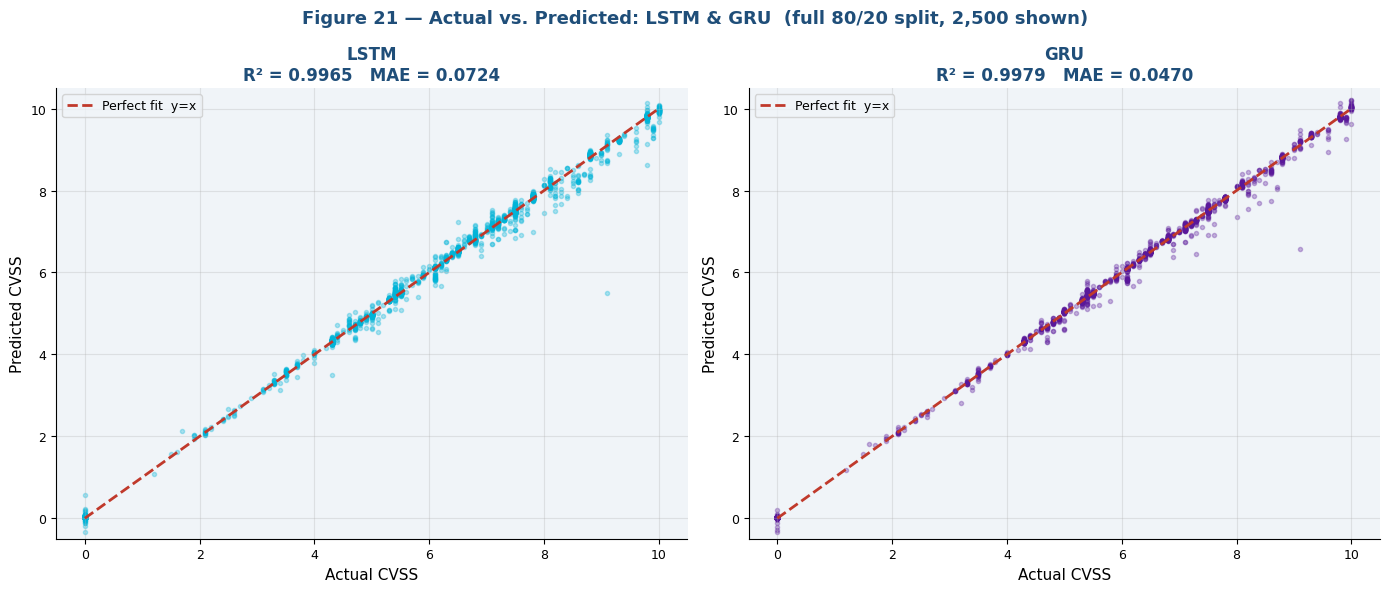

✓ Figure 21 saved


In [34]:
# Figure 21 — Actual vs Predicted (LSTM & GRU)
dl_preds = {'LSTM': yp_lstm, 'GRU': yp_gru}
dl_res   = {
    'LSTM': {'MAE': lstm_mae, 'RMSE': lstm_rmse, 'R2': lstm_r2},
    'GRU' : {'MAE': gru_mae,  'RMSE': gru_rmse,  'R2': gru_r2},
}
dl_cols = [CYAN, PURPLE]

plot_idx2 = np.random.default_rng(42).choice(len(y_te), 2500, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, pred), col in zip(axes, dl_preds.items(), dl_cols):
    ax.scatter(y_te[plot_idx2], pred[plot_idx2], alpha=0.3, s=9, color=col)
    ax.plot([0,10],[0,10], color=RED, lw=2, linestyle='--', label='Perfect fit  y=x')
    ax.set_title(f'{name}\nR² = {dl_res[name]["R2"]:.4f}   MAE = {dl_res[name]["MAE"]:.4f}',
                 fontsize=12, fontweight='bold', color=DARK)
    ax.set_xlabel('Actual CVSS'); ax.set_ylabel('Predicted CVSS')
    ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.5, 10.5)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Figure 21 — Actual vs. Predicted: LSTM & GRU  (full 80/20 split, 2,500 shown)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig21_avp_dl.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 21 saved")


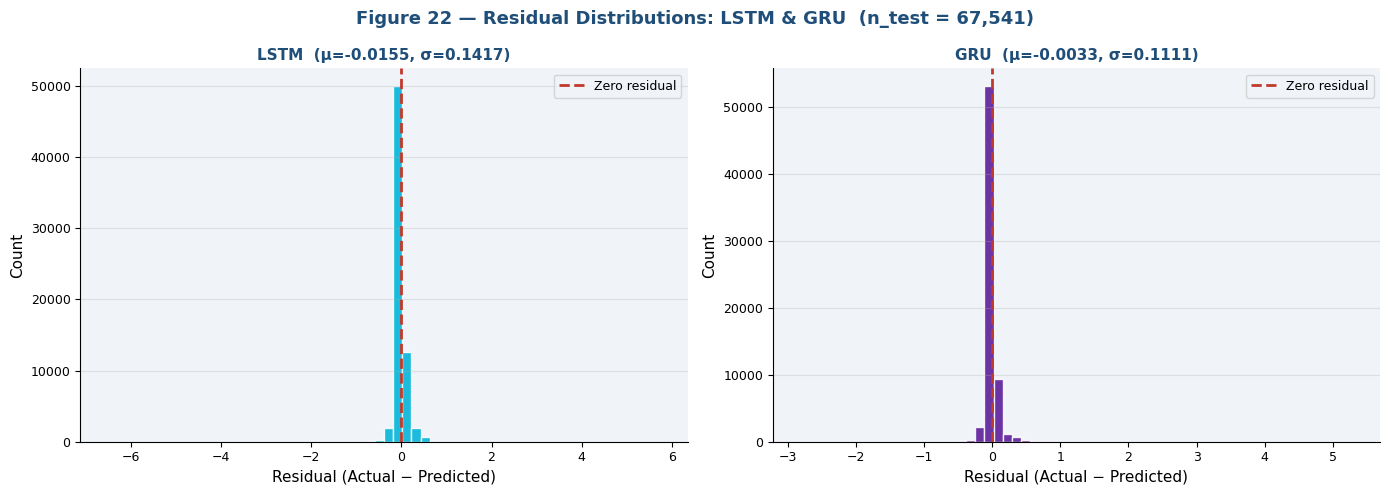

✓ Figure 22 saved


In [35]:
# Figure 22 — Residuals (LSTM & GRU)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred), col in zip(axes, dl_preds.items(), dl_cols):
    res = y_te - pred
    ax.hist(res, bins=60, color=col, edgecolor='white', alpha=0.88)
    ax.axvline(0, color=RED, lw=2, linestyle='--', label='Zero residual')
    ax.set_title(f'{name}  (μ={res.mean():+.4f}, σ={res.std():.4f})',
                 fontsize=11, fontweight='bold', color=DARK)
    ax.set_xlabel('Residual (Actual − Predicted)'); ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Figure 22 — Residual Distributions: LSTM & GRU  (n_test = 67,541)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig22_residuals_dl.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 22 saved")


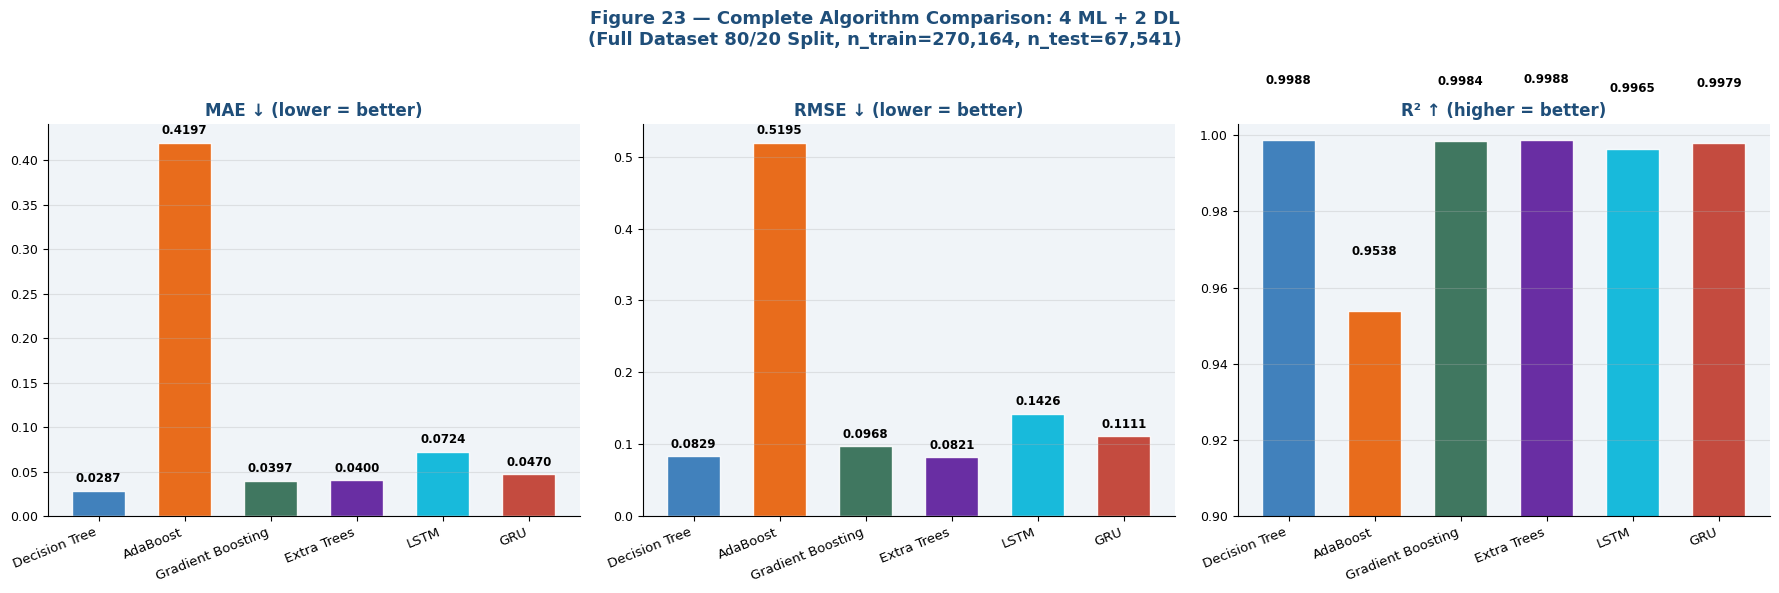

✓ Figure 23 saved


In [36]:
# Figure 23 — Complete 6-Algorithm Comparison
all_results = {**ml_results,
               'LSTM': {'MAE': lstm_mae, 'RMSE': lstm_rmse, 'R2': lstm_r2},
               'GRU' : {'MAE': gru_mae,  'RMSE': gru_rmse,  'R2': gru_r2}}
all_labels  = list(all_results.keys())
all_colours = [MID, ORANGE, GREEN, PURPLE, CYAN, RED]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (met, ttl) in enumerate([('MAE','MAE ↓ (lower = better)'),
                                  ('RMSE','RMSE ↓ (lower = better)'),
                                  ('R2','R² ↑ (higher = better)')]):
    ax   = axes[i]
    vals = [all_results[n][met] for n in all_labels]
    bars = ax.bar(range(len(vals)), vals, color=all_colours,
                  edgecolor='white', alpha=0.9, width=0.62)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(all_labels, rotation=22, ha='right', fontsize=9.5)
    ax.set_title(ttl, fontsize=12, fontweight='bold', color=DARK)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.014,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if met == 'R2': ax.set_ylim(0.90, 1.003)

fig.suptitle('Figure 23 — Complete Algorithm Comparison: 4 ML + 2 DL\n'
             '(Full Dataset 80/20 Split, n_train=270,164, n_test=67,541)',
             fontsize=13, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('fig23_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 23 saved")


In [37]:
# Final results summary — clean table format
print("=" * 75)
print("  COMPLETE RESULTS — All 6 Algorithms  (n_test = 67,541)")
print("=" * 75)
print(f"  {'Algorithm':<24} {'MAE':>8} {'RMSE':>8} {'R²':>8}  {'CV R²':<20} {'Time'}")
print("-" * 75)

for name in ml_results:
    cv_str = f"{cv_results[name]['mean']:.4f}±{cv_results[name]['std']:.4f}"
    r      = ml_results[name]
    flag   = "  ★" if name == 'Extra Trees' else ""
    print(f"  {name:<24} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f}  "
          f"{cv_str:<20} {r['time']:.1f}s{flag}")

print("-" * 75)
for name, (mae, rmse, r2, t) in [
    ('LSTM', (lstm_mae, lstm_rmse, lstm_r2, lstm_time)),
    ('GRU',  (gru_mae,  gru_rmse,  gru_r2,  gru_time)),
]:
    print(f"  {name:<24} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}  {'— (full 270k)':<20} {t:.1f}s")

print("=" * 75)
print("  ★ Extra Trees: Best CV R² = 0.9990 ± 0.0001 — recommended for deployment")


  COMPLETE RESULTS — All 6 Algorithms  (n_test = 67,541)
  Algorithm                     MAE     RMSE       R²  CV R²                Time
---------------------------------------------------------------------------
  Decision Tree              0.0287   0.0829   0.9988  0.9988±0.0003        0.7s
  AdaBoost                   0.4197   0.5195   0.9538  0.9329±0.0021        40.4s
  Gradient Boosting          0.0397   0.0968   0.9984  0.9969±0.0002        43.3s
  Extra Trees                0.0400   0.0821   0.9988  0.9990±0.0001        26.0s  ★
---------------------------------------------------------------------------
  LSTM                       0.0724   0.1426   0.9965  — (full 270k)        226.7s
  GRU                        0.0470   0.1111   0.9979  — (full 270k)        105.1s
  ★ Extra Trees: Best CV R² = 0.9990 ± 0.0001 — recommended for deployment


## Step 9 — Save All Trained Models

We persist all **4 ML models** and **2 DL models** to disk using `joblib`.  
We also save the **StandardScaler** (needed to transform any new data before feeding it to LSTM/GRU), and a **metadata JSON** file with all hyperparameters and results.

After running this cell, you'll see all files appear in the Colab file browser (📂 icon on the left).


In [38]:
# ── Create output directory ───────────────────────────────────────────────────
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving all models to: ./{SAVE_DIR}/")
print("-" * 55)

# ── Save ML models ────────────────────────────────────────────────────────────
for name, model in ml_models.items():
    fname = name.lower().replace(' ', '_')
    path  = f'{SAVE_DIR}/model_{fname}.pkl'
    joblib.dump(model, path, compress=3)
    size  = os.path.getsize(path) / 1024
    print(f"  ✓ {name:<22}  →  {path}  ({size:.0f} KB)")

# ── Save DL models ────────────────────────────────────────────────────────────
joblib.dump(lstm_model, f'{SAVE_DIR}/model_lstm.pkl', compress=3)
sz = os.path.getsize(f'{SAVE_DIR}/model_lstm.pkl') / 1024
print(f"  ✓ LSTM Regressor       →  {SAVE_DIR}/model_lstm.pkl  ({sz:.0f} KB)")

joblib.dump(gru_model, f'{SAVE_DIR}/model_gru.pkl', compress=3)
sz = os.path.getsize(f'{SAVE_DIR}/model_gru.pkl') / 1024
print(f"  ✓ GRU Regressor        →  {SAVE_DIR}/model_gru.pkl   ({sz:.0f} KB)")

# ── Save scalers ──────────────────────────────────────────────────────────────
joblib.dump(sc_std, f'{SAVE_DIR}/scaler_standard.pkl')
joblib.dump(sc_mm,  f'{SAVE_DIR}/scaler_minmax.pkl')
print(f"  ✓ StandardScaler       →  {SAVE_DIR}/scaler_standard.pkl")
print(f"  ✓ MinMaxScaler         →  {SAVE_DIR}/scaler_minmax.pkl")

# ── Save metadata JSON ────────────────────────────────────────────────────────
metadata = {
    'student'     : 'Nisarg Chasmawala',
    'student_id'  : '25155511',
    'module'      : 'CMP7239',
    'dataset'     : 'NVD_Cybersecurity_Dataset.csv',
    'n_records'   : int(len(X)),
    'n_train'     : int(len(X_tr)),
    'n_test'      : int(len(X_te)),
    'features'    : FEATURES,
    'target'      : TARGET,
    'split'       : '80/20',
    'random_state': 42,
    'ml_results'  : {
        k: {'MAE': round(v['MAE'],4), 'RMSE': round(v['RMSE'],4),
            'R2': round(v['R2'],4), 'CV_mean': round(cv_results[k]['mean'],4),
            'CV_std': round(cv_results[k]['std'],4)}
        for k, v in ml_results.items()
    },
    'dl_results'  : {
        'LSTM': {'MAE': round(lstm_mae,4), 'RMSE': round(lstm_rmse,4), 'R2': round(lstm_r2,4)},
        'GRU' : {'MAE': round(gru_mae,4),  'RMSE': round(gru_rmse,4),  'R2': round(gru_r2,4)},
    },
    'feature_selection': {
        'lasso_alpha'  : round(lasso.alpha_, 6),
        'en_alpha'     : round(en.alpha_, 6),
        'en_l1_ratio'  : round(en.l1_ratio_, 4),
        'lasso_nonzero': int(sum(abs(lasso.coef_) > 1e-6)),
        'en_nonzero'   : int(sum(abs(en.coef_) > 1e-6)),
        'rfe_selected' : [FEATURES[i] for i in range(13) if rfe.ranking_[i]==1],
    }
}

with open(f'{SAVE_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"  ✓ Metadata             →  {SAVE_DIR}/model_metadata.json")

print()
print("=" * 55)
print("  ALL MODELS SAVED SUCCESSFULLY")
print("=" * 55)
print(f"  Files in ./{SAVE_DIR}/:")
for fn in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(f'{SAVE_DIR}/{fn}') / 1024
    print(f"    {fn:<40}  {sz:>7.0f} KB")

# ── Quick load test — make sure the best model can be reloaded ────────────────
print()
print("Quick reload test — Extra Trees (best CV model):")
loaded_model = joblib.load(f'{SAVE_DIR}/model_extra_trees.pkl')
test_pred    = loaded_model.predict(X_te[:5])
print(f"  Sample predictions : {test_pred.round(3).tolist()}")
print(f"  Actual values      : {y_te[:5].round(3).tolist()}")
print("  ✓ Model loads and predicts correctly")

# ── Show how to use any saved model on new data ────────────────────────────────
print()
print("─" * 55)
print("  HOW TO LOAD AND USE A SAVED MODEL ON NEW DATA:")
print("─" * 55)
print("""
  import joblib, numpy as np

  # Load the model and scaler
  model  = joblib.load('saved_models/model_extra_trees.pkl')
  # (DL models also need the scaler)
  scaler = joblib.load('saved_models/scaler_standard.pkl')

  # Prepare new CVE features (13 values in the same order as FEATURES)
  X_new  = np.array([[3.9, 10.0, 27, 158, 2024, 6,
                       0, 0, 1, 0, 0, 0, 0]])

  # ML model — predict directly
  pred_ml = model.predict(X_new)
  print(f'ML prediction  : {pred_ml[0]:.2f}')

  # DL model — scale first
  lstm   = joblib.load('saved_models/model_lstm.pkl')
  X_sc   = scaler.transform(X_new)
  pred_dl = lstm.predict(X_sc)
  print(f'LSTM prediction: {pred_dl[0]:.2f}')
""")


Saving all models to: ./saved_models/
-------------------------------------------------------
  ✓ Decision Tree           →  saved_models/model_decision_tree.pkl  (10 KB)
  ✓ AdaBoost                →  saved_models/model_adaboost.pkl  (54 KB)
  ✓ Gradient Boosting       →  saved_models/model_gradient_boosting.pkl  (102 KB)
  ✓ Extra Trees             →  saved_models/model_extra_trees.pkl  (3919 KB)
  ✓ LSTM Regressor       →  saved_models/model_lstm.pkl  (281 KB)
  ✓ GRU Regressor        →  saved_models/model_gru.pkl   (159 KB)
  ✓ StandardScaler       →  saved_models/scaler_standard.pkl
  ✓ MinMaxScaler         →  saved_models/scaler_minmax.pkl
  ✓ Metadata             →  saved_models/model_metadata.json

  ALL MODELS SAVED SUCCESSFULLY
  Files in ./saved_models/:
    model_adaboost.pkl                             54 KB
    model_decision_tree.pkl                        10 KB
    model_extra_trees.pkl                        3919 KB
    model_gradient_boosting.pkl                   102